# Pengujian Model FFNN
## Dataset: Global Student Placement and Salary

Pengujian akan pengaruh berbagai hyperparameter terhadap model FFNN:
1. **Depth & Width**
2. **Fungsi Aktivasi** 
3. **Learning Rate** 
4. **Regularisasi** 
5. **Perbandingan sklearn MLP** 

---
## 0. Setup & Preprocessing

In [57]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')

from model import FFNN
from activation_function import ActivationFunctions
from loss_function import LossFunctions
from initialization import Initialization

np.random.seed(42)

In [58]:
# Load dataset
df = pd.read_csv('../data/datasetml_2026.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (10000, 12)
Columns: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [59]:
# Cek info dataset
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Target distribution:')
print(df['placement_status'].value_counts())

Data types:
cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

Missing values:
cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

Target distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


In [60]:
# Preprocessing

# Encode target
df['placement_status'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

# One-hot encode kolom kategorikal
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {categorical_cols}')
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Pisahkan fitur dan target
X = df.drop('placement_status', axis=1).values.astype(np.float64)
y = df['placement_status'].values.astype(np.float64)

# One-hot encode target 
y_onehot = np.zeros((len(y), 2))
y_onehot[np.arange(len(y)), y.astype(int)] = 1

print(f'X shape: {X.shape}')
print(f'y_onehot shape: {y_onehot.shape}')

Categorical columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
X shape: (10000, 23)
y_onehot shape: (10000, 2)


In [61]:
# Normalisasi fitur 
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1  # hindari division by zero
X_norm = (X - X_min) / X_range

# Split train 
n = len(X_norm)
indices = np.random.permutation(n)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X_norm[indices[:train_end]]
y_train = y_onehot[indices[:train_end]]
X_val   = X_norm[indices[train_end:val_end]]
y_val   = y_onehot[indices[train_end:val_end]]
X_test  = X_norm[indices[val_end:]]
y_test  = y_onehot[indices[val_end:]]

n_features = X_train.shape[1]
n_classes = 2

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')
print(f'Features: {n_features}, Classes: {n_classes}')

Train: 7000, Val: 1500, Test: 1500
Features: 23, Classes: 2


In [62]:
# Helper Function

# hitung akurasi
def accuracy(model, X, y_true):
    y_pred = model.predict(X)
    pred_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    return np.mean(pred_labels == true_labels)

# ringkasan eksperimen
def print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    train_acc = accuracy(model, X_train, y_train)
    val_acc = accuracy(model, X_val, y_val)
    test_acc = accuracy(model, X_test, y_test)
    print(f'{name}:')
    print(f'  Train Accuracy: {train_acc:.4f}')
    print(f'  Val Accuracy:   {val_acc:.4f}')
    print(f'  Test Accuracy:  {test_acc:.4f}')
    return {'name': name, 'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc}

# plot perbandingan loss
def compare_loss(models_dict, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for name, model in models_dict.items():
        ax1.plot(model.history['train_loss'], label=name)
        if model.history['val_loss']:
            ax2.plot(model.history['val_loss'], label=name)
    ax1.set_title(f'{title} — Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.set_title(f'{title} (Validation Loss)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# plot perbandingan akurasi (bar chart)
def compare_accuracy_bar(results_list, title):
    names = [r['name'] for r in results_list]
    train_accs = [r['train_acc'] for r in results_list]
    val_accs = [r['val_acc'] for r in results_list]
    test_accs = [r['test_acc'] for r in results_list]
    
    x = np.arange(len(names))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, train_accs, width, label='Train', alpha=0.8)
    ax.bar(x, val_accs, width, label='Validation', alpha=0.8)
    ax.bar(x + width, test_accs, width, label='Test', alpha=0.8)
    ax.set_xlabel('Eksperimen')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print('Helper functions loaded.')

Helper functions loaded.


---
## 1. Pengaruh Depth (Banyak Layer) dan Width (Banyak Neuron per Layer)

### 1a. Variasi Width (depth tetap = 3 hidden layers)

In [63]:
EPOCHS = 50
LR = 0.01
BATCH = 32

width_configs = {
    'Width=16':  [n_features, 16, 16, 16, n_classes],
    'Width=64':  [n_features, 64, 64, 64, n_classes],
    'Width=128': [n_features, 128, 128, 128, n_classes],
}

width_models = {}
width_results = []

for name, sizes in width_configs.items():
    print(f'\n- Training {name}')
    n_hidden = len(sizes) - 2  # jumlah hidden layer
    acts = ['relu'] * n_hidden + ['softmax']
    
    model = FFNN(
        layer_sizes=sizes,
        activations=acts,
        loss='categorical_cross_entropy',
        init_method='he',
        init_params={'distribution': 'normal', 'seed': 42}
    )
    model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0)
    width_models[name] = model
    res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
    width_results.append(res)


- Training Width=16


Width=16:
  Train Accuracy: 0.7651
  Val Accuracy:   0.7253
  Test Accuracy:  0.7320

- Training Width=64
Width=64:
  Train Accuracy: 0.7780
  Val Accuracy:   0.7400
  Test Accuracy:  0.7267

- Training Width=128
Width=128:
  Train Accuracy: 0.7959
  Val Accuracy:   0.7413
  Test Accuracy:  0.7373


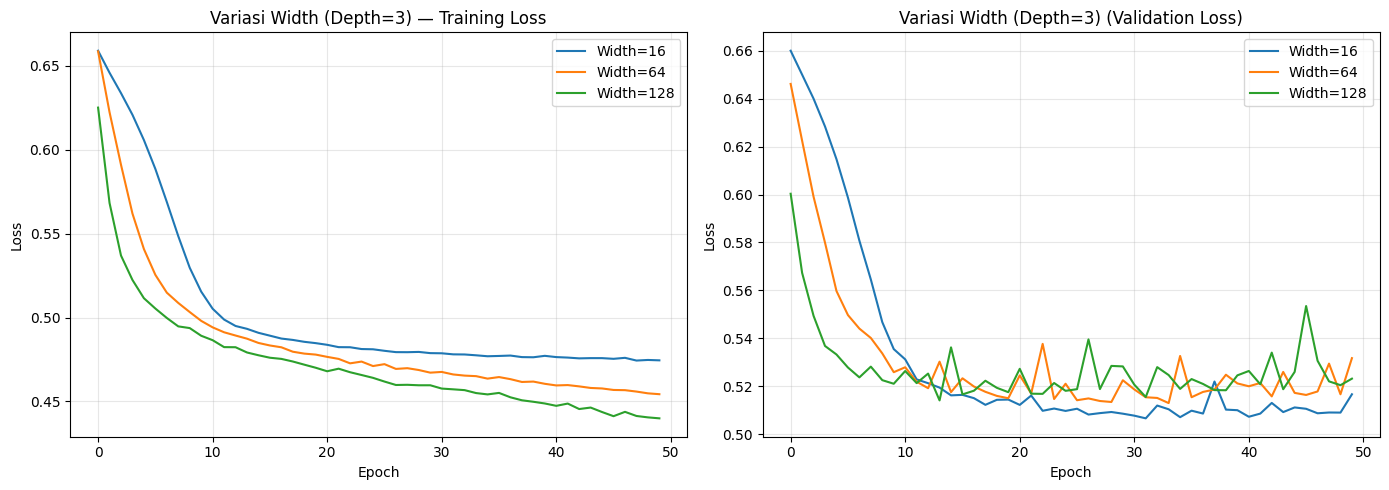

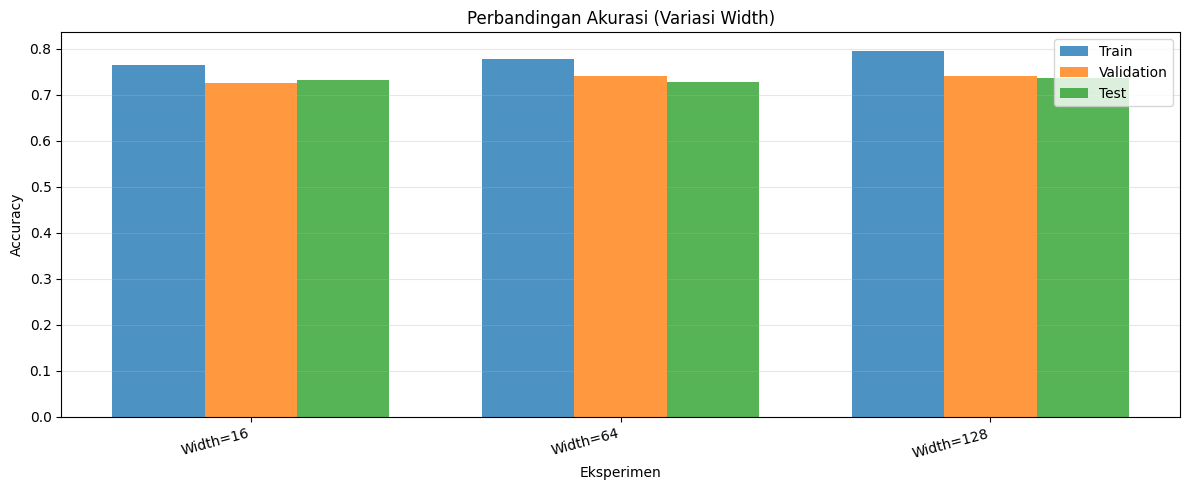

In [64]:
compare_loss(width_models, 'Variasi Width (Depth=3)')
compare_accuracy_bar(width_results, 'Perbandingan Akurasi (Variasi Width)')

### 1b. Variasi Depth (width tetap = 64 per hidden layer)

In [65]:
depth_configs = {
    'Depth=1': [n_features, 64, n_classes],
    'Depth=3': [n_features, 64, 64, 64, n_classes],
    'Depth=5': [n_features, 64, 64, 64, 64, 64, n_classes],
}

depth_models = {}
depth_results = []

for name, sizes in depth_configs.items():
    print(f'\n- Training {name}')
    n_hidden = len(sizes) - 2
    acts = ['relu'] * n_hidden + ['softmax']
    
    model = FFNN(
        layer_sizes=sizes,
        activations=acts,
        loss='categorical_cross_entropy',
        init_method='he',
        init_params={'distribution': 'normal', 'seed': 42}
    )
    model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0)
    depth_models[name] = model
    res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
    depth_results.append(res)


- Training Depth=1
Depth=1:
  Train Accuracy: 0.7684
  Val Accuracy:   0.7473
  Test Accuracy:  0.7333

- Training Depth=3
Depth=3:
  Train Accuracy: 0.7867
  Val Accuracy:   0.7387
  Test Accuracy:  0.7313

- Training Depth=5
Depth=5:
  Train Accuracy: 0.8114
  Val Accuracy:   0.7460
  Test Accuracy:  0.7307


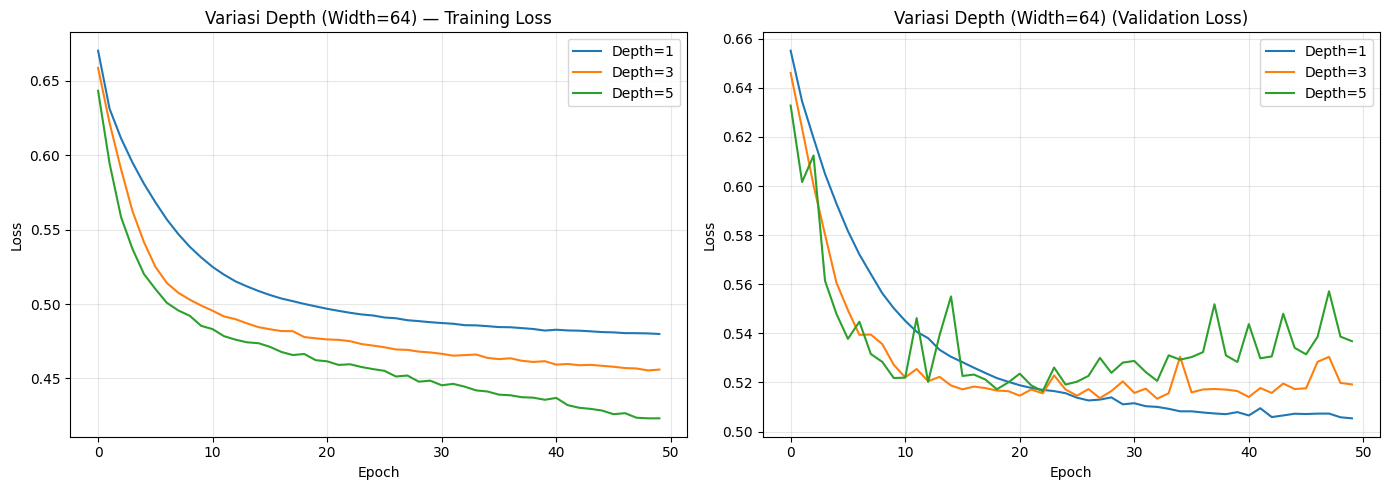

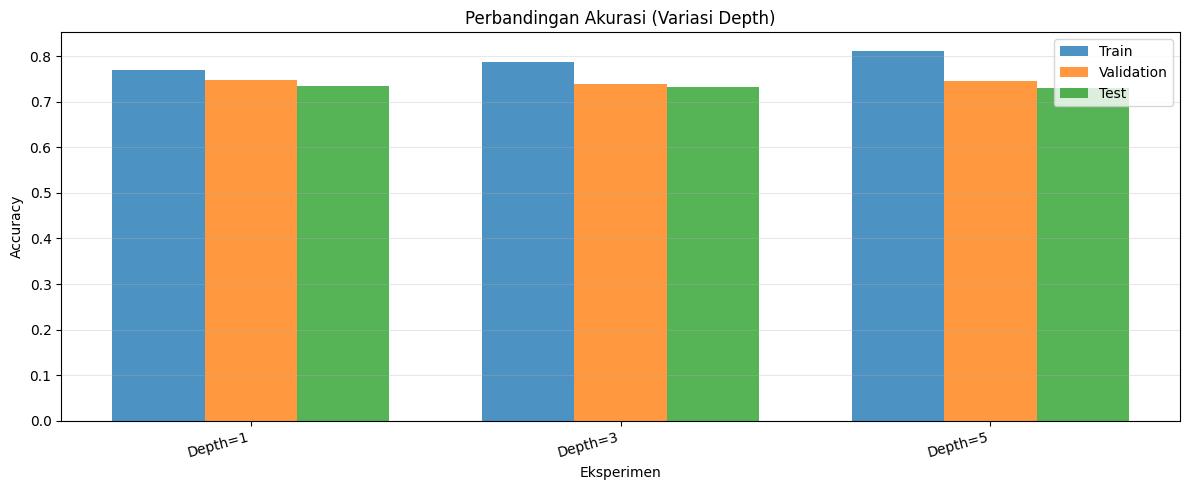

In [66]:
compare_loss(depth_models, 'Variasi Depth (Width=64)')
compare_accuracy_bar(depth_results, 'Perbandingan Akurasi (Variasi Depth)')

---
## 2. Pengaruh Fungsi Aktivasi Hidden Layer
**Base arsitektur:** 4 layer  
**Layer pengetesan:** Layer ke-2 (hidden layer tengah)  
**Variasi fungsi aktivasi yang diuji:** linear, relu, sigmoid, tanh, elu, swish (semua kecuali softmax)

In [67]:
activation_names = ['linear', 'relu', 'sigmoid', 'tanh', 'elu', 'swish']

act_models = {}
act_results = []

for act_name in activation_names:
    print(f'\n- Aktivasi: {act_name}')
    # Layer 1: relu, Layer 2: variasi, Layer 3: relu, Output: softmax
    acts = ['relu', act_name, 'relu', 'softmax']
    
    model = FFNN(
        layer_sizes=[n_features, 64, 64, 64, n_classes],
        activations=acts,
        loss='categorical_cross_entropy',
        init_method='he',
        init_params={'distribution': 'normal', 'seed': 42}
    )
    model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0)
    act_models[act_name] = model
    res = print_results(act_name, model, X_train, y_train, X_val, y_val, X_test, y_test)
    act_results.append(res)


- Aktivasi: linear
linear:
  Train Accuracy: 0.7801
  Val Accuracy:   0.7480
  Test Accuracy:  0.7420

- Aktivasi: relu
relu:
  Train Accuracy: 0.7870
  Val Accuracy:   0.7393
  Test Accuracy:  0.7313

- Aktivasi: sigmoid
sigmoid:
  Train Accuracy: 0.7680
  Val Accuracy:   0.7467
  Test Accuracy:  0.7407

- Aktivasi: tanh
tanh:
  Train Accuracy: 0.7803
  Val Accuracy:   0.7460
  Test Accuracy:  0.7313

- Aktivasi: elu
elu:
  Train Accuracy: 0.7813
  Val Accuracy:   0.7420
  Test Accuracy:  0.7347

- Aktivasi: swish
swish:
  Train Accuracy: 0.7793
  Val Accuracy:   0.7453
  Test Accuracy:  0.7380


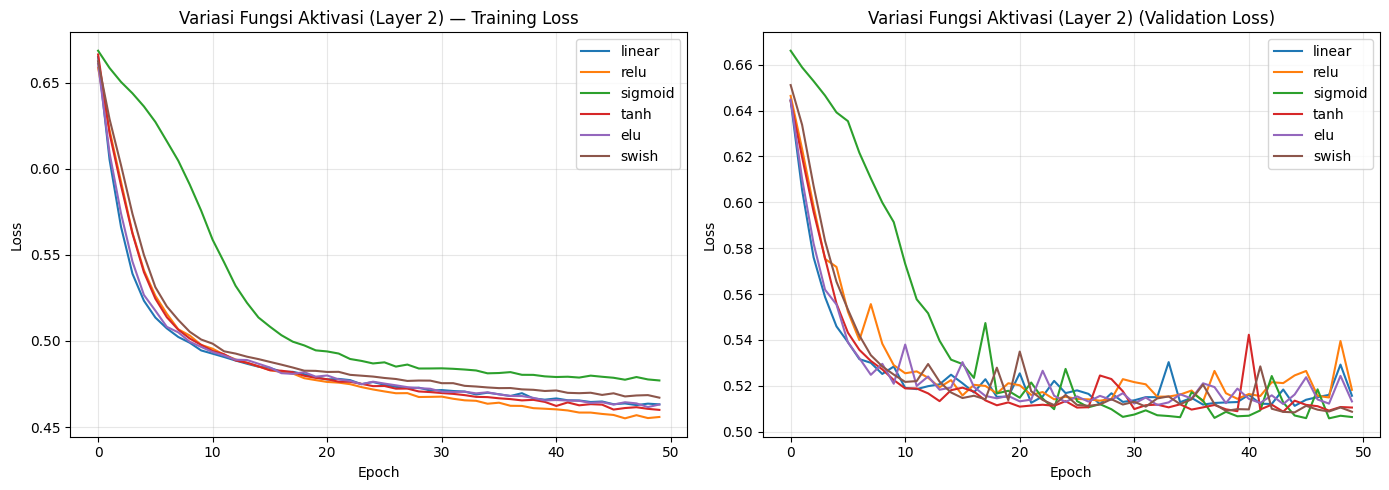

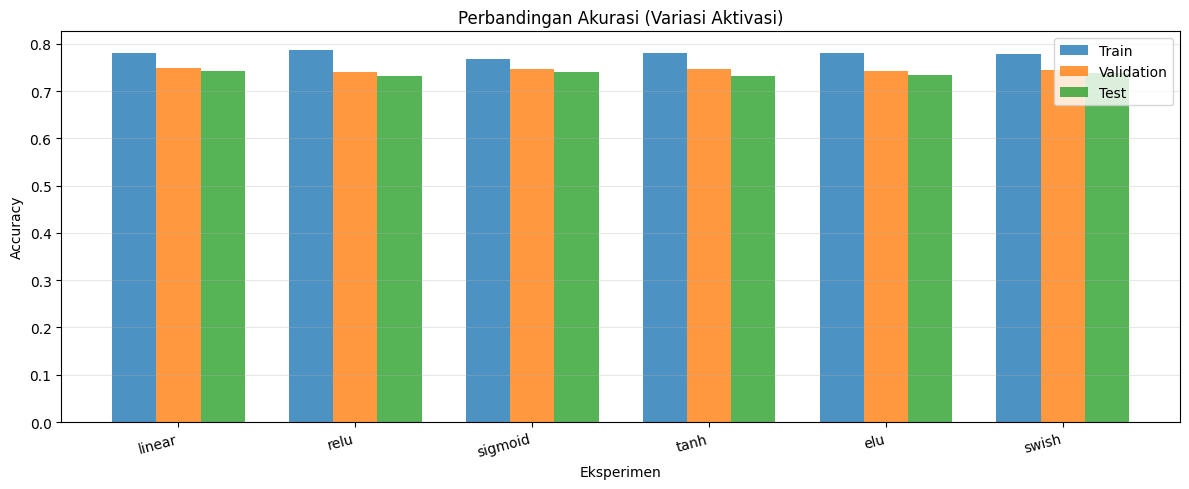

In [68]:
compare_loss(act_models, 'Variasi Fungsi Aktivasi (Layer 2)')
compare_accuracy_bar(act_results, 'Perbandingan Akurasi (Variasi Aktivasi)')


- Aktivasi: linear


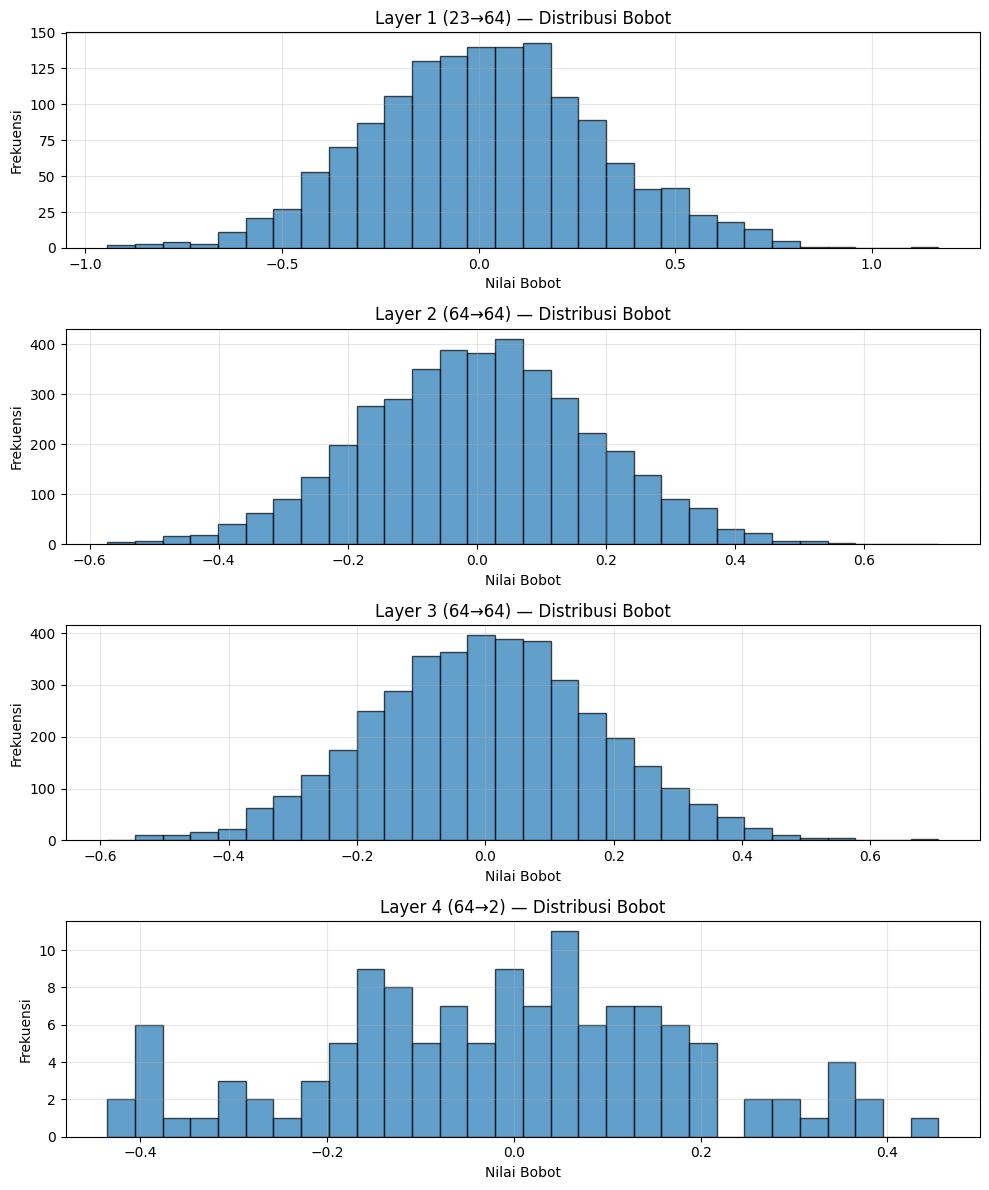

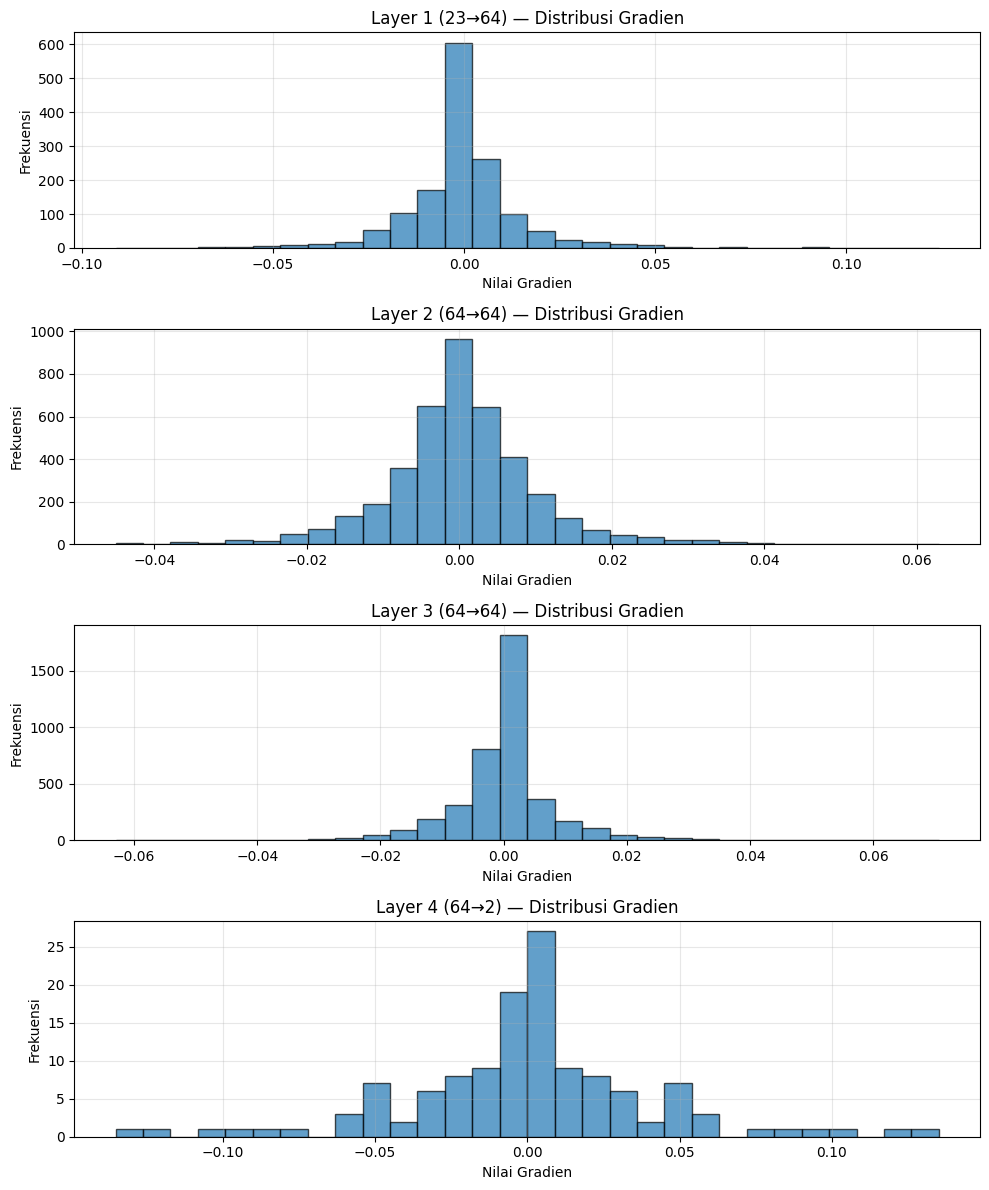


- Aktivasi: relu


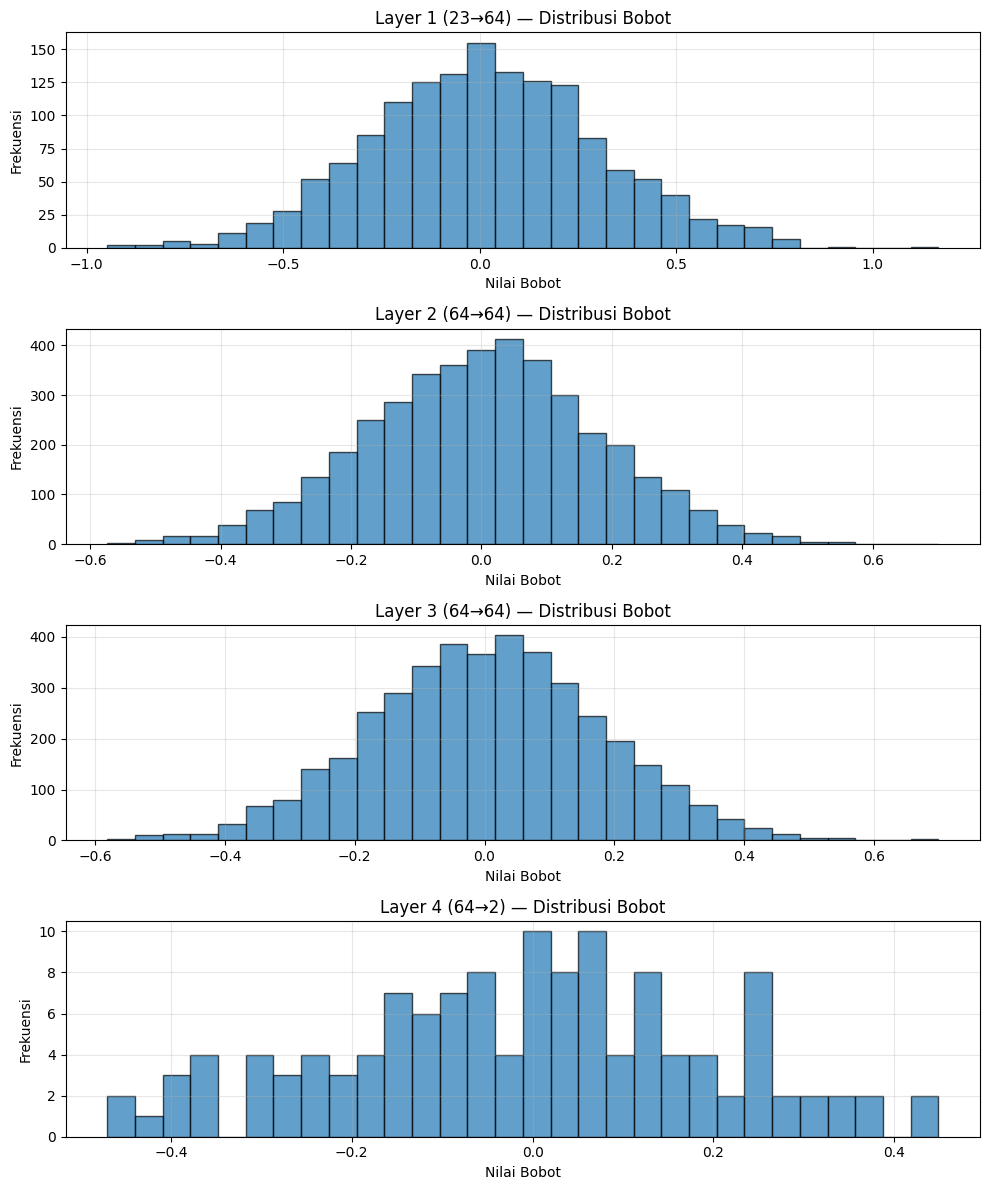

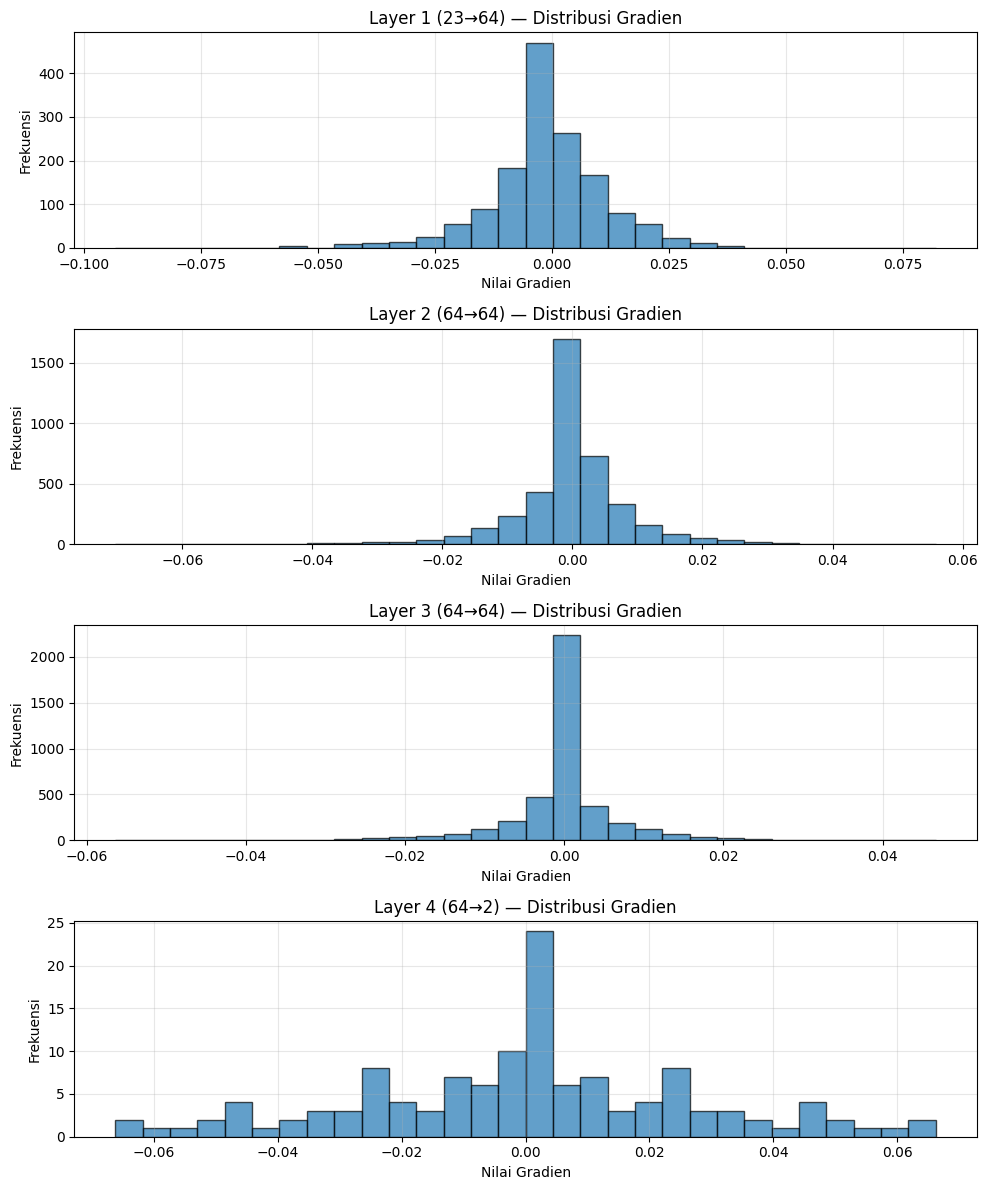


- Aktivasi: sigmoid


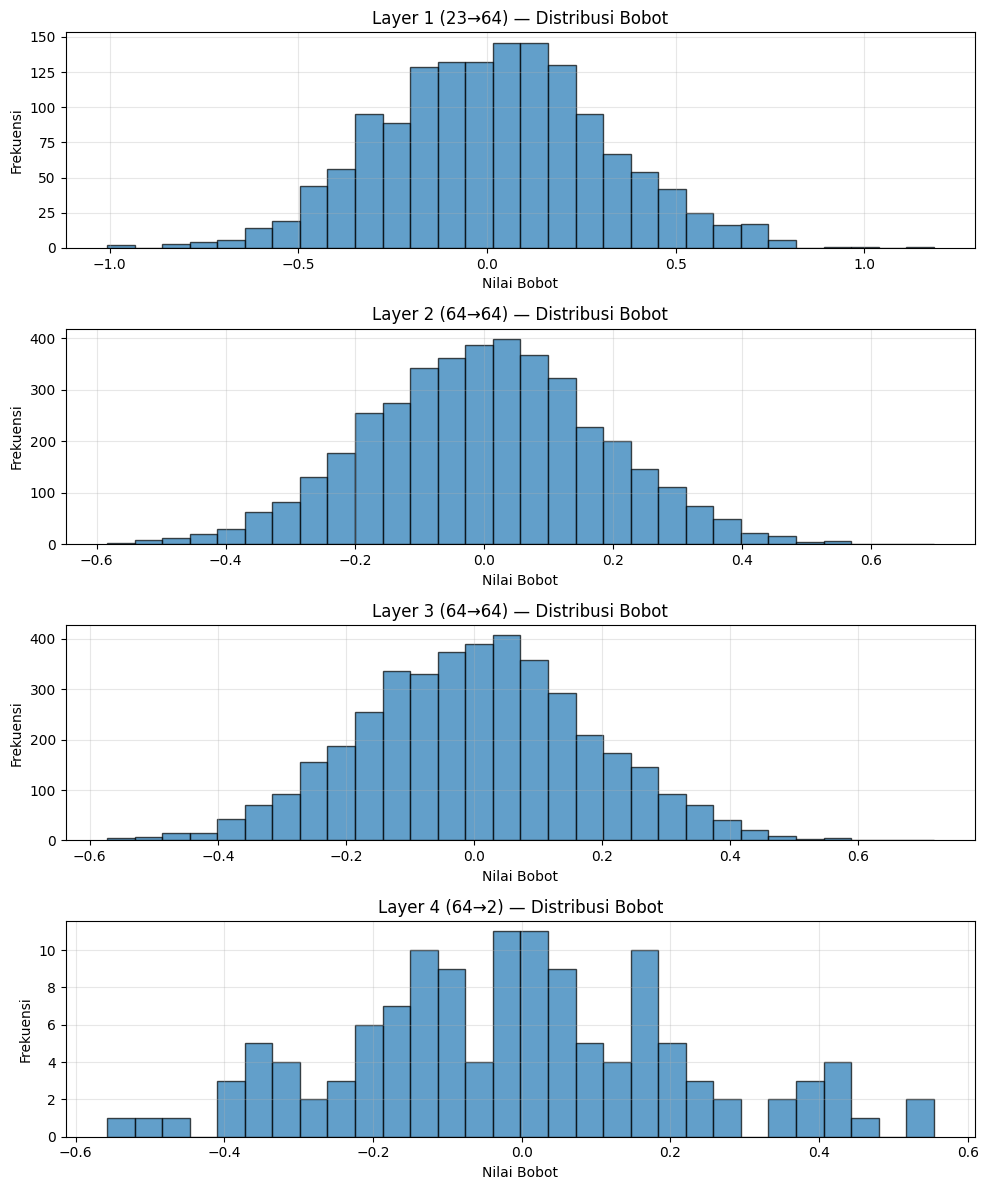

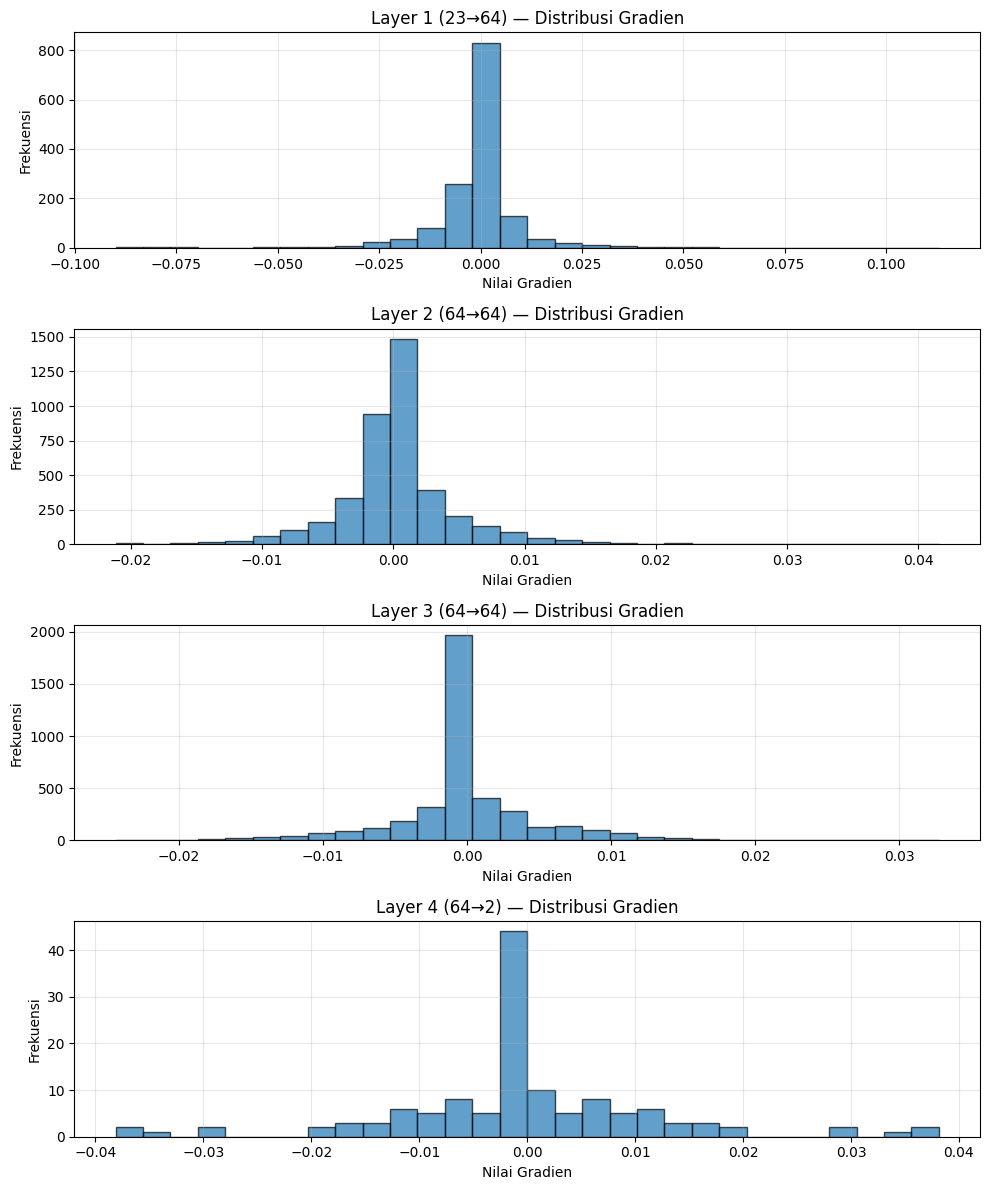


- Aktivasi: tanh


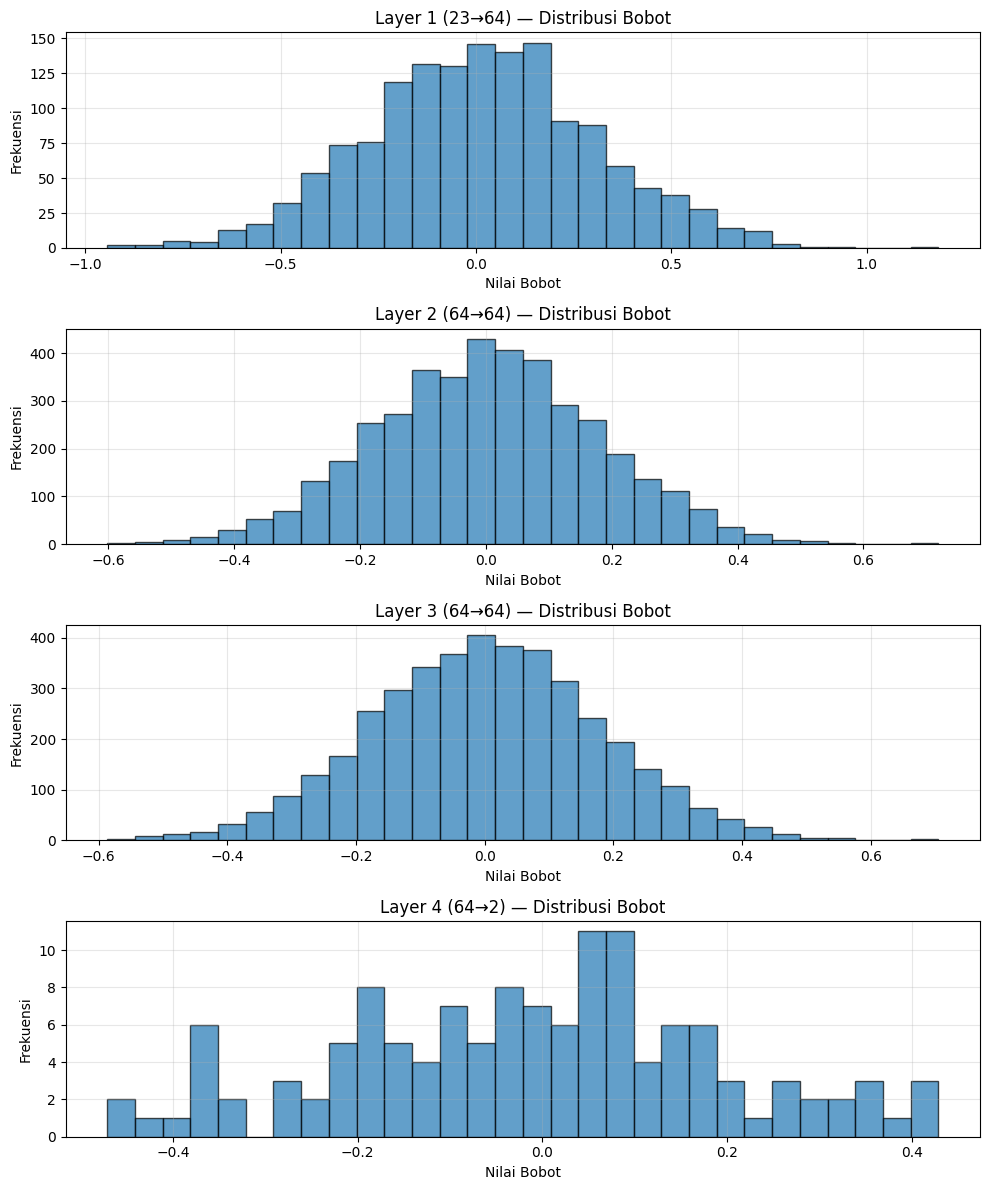

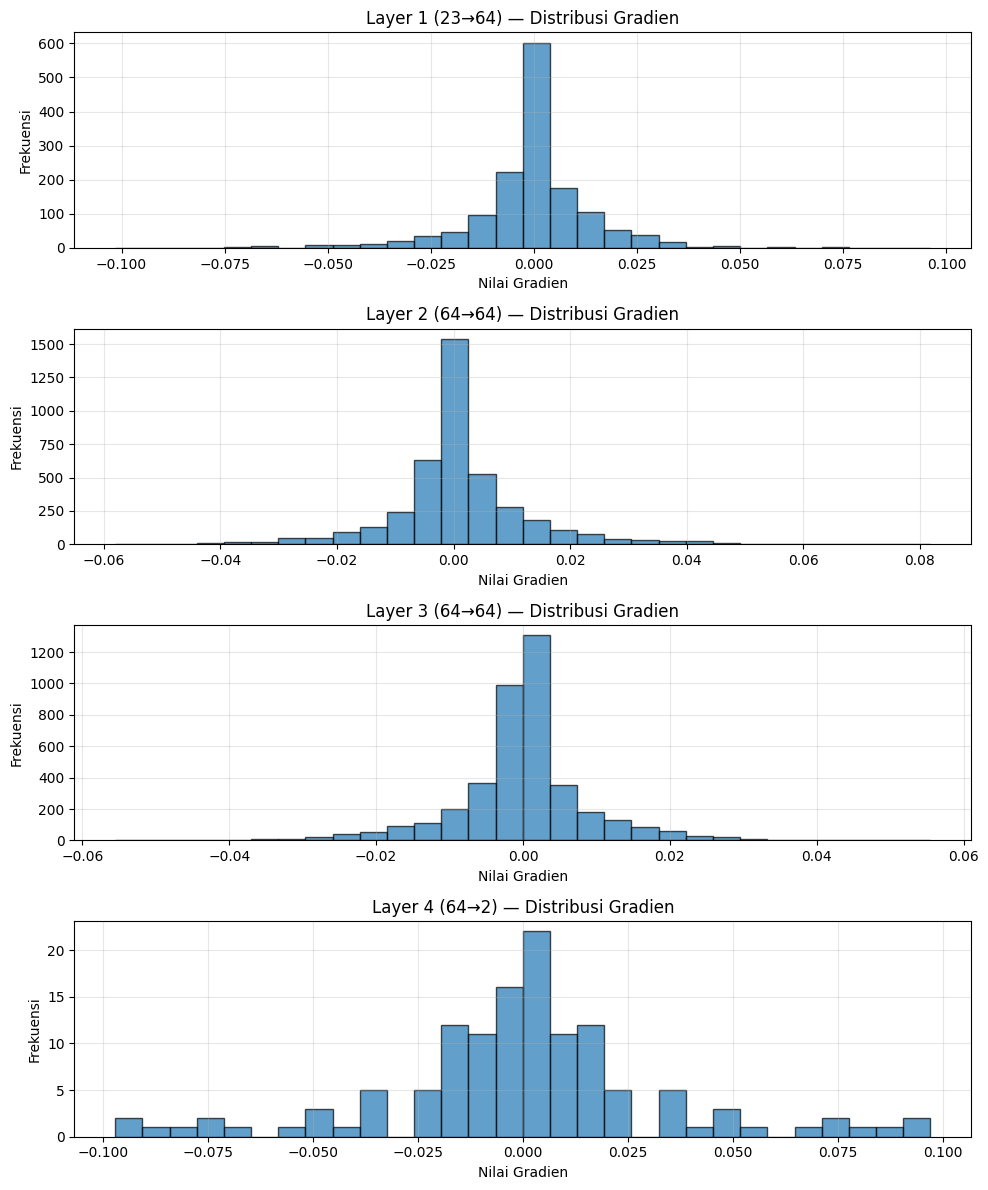


- Aktivasi: elu


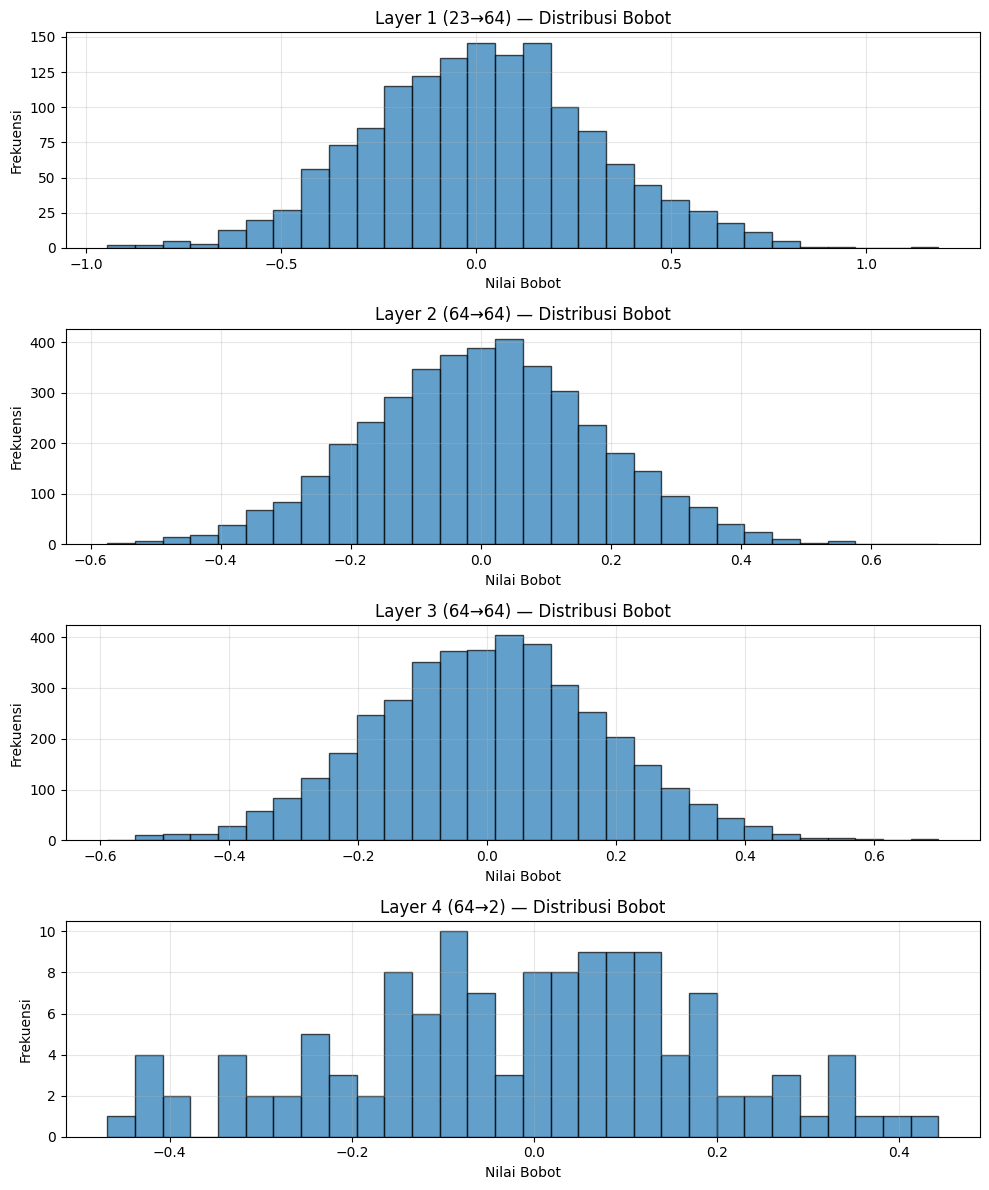

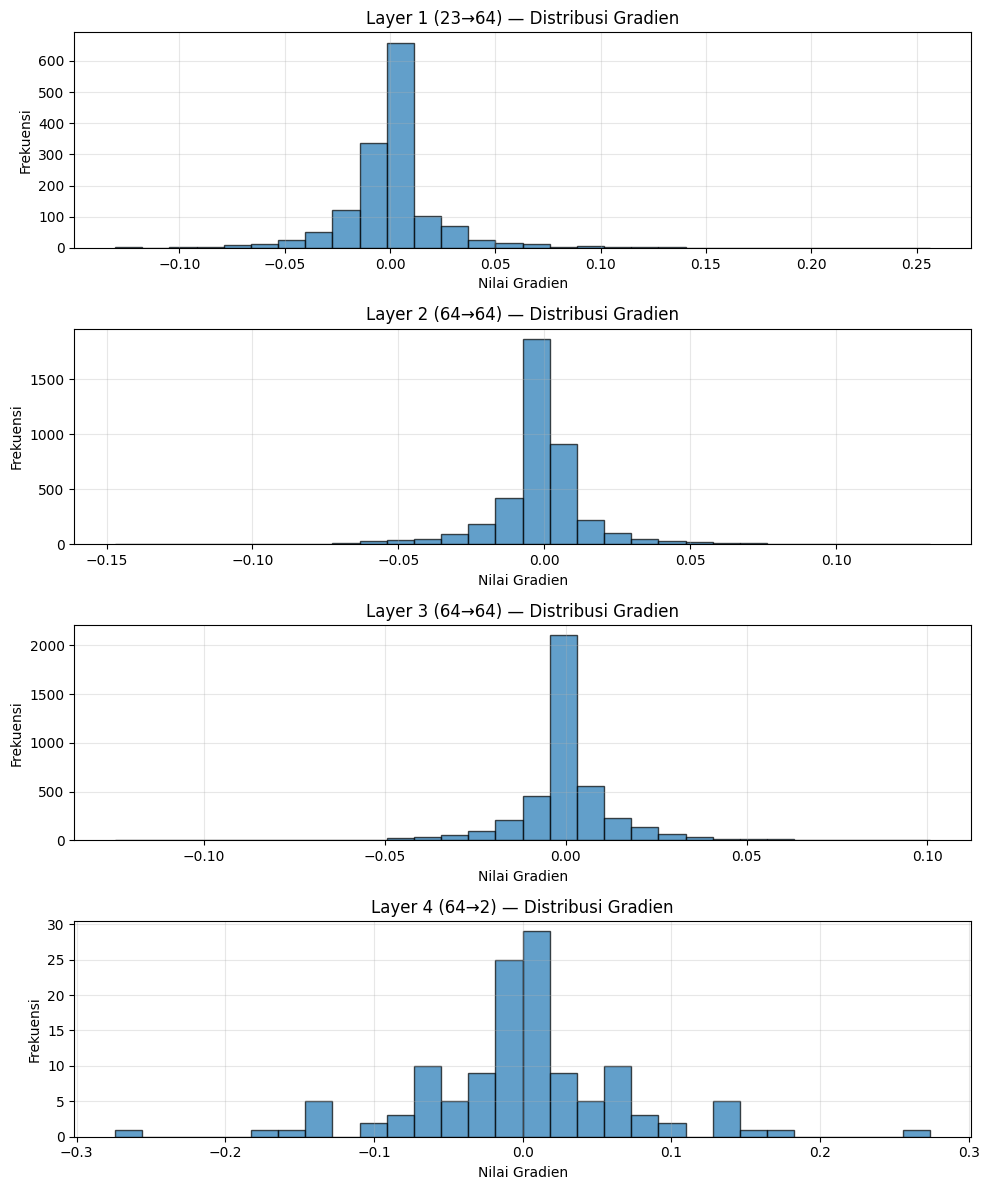


- Aktivasi: swish


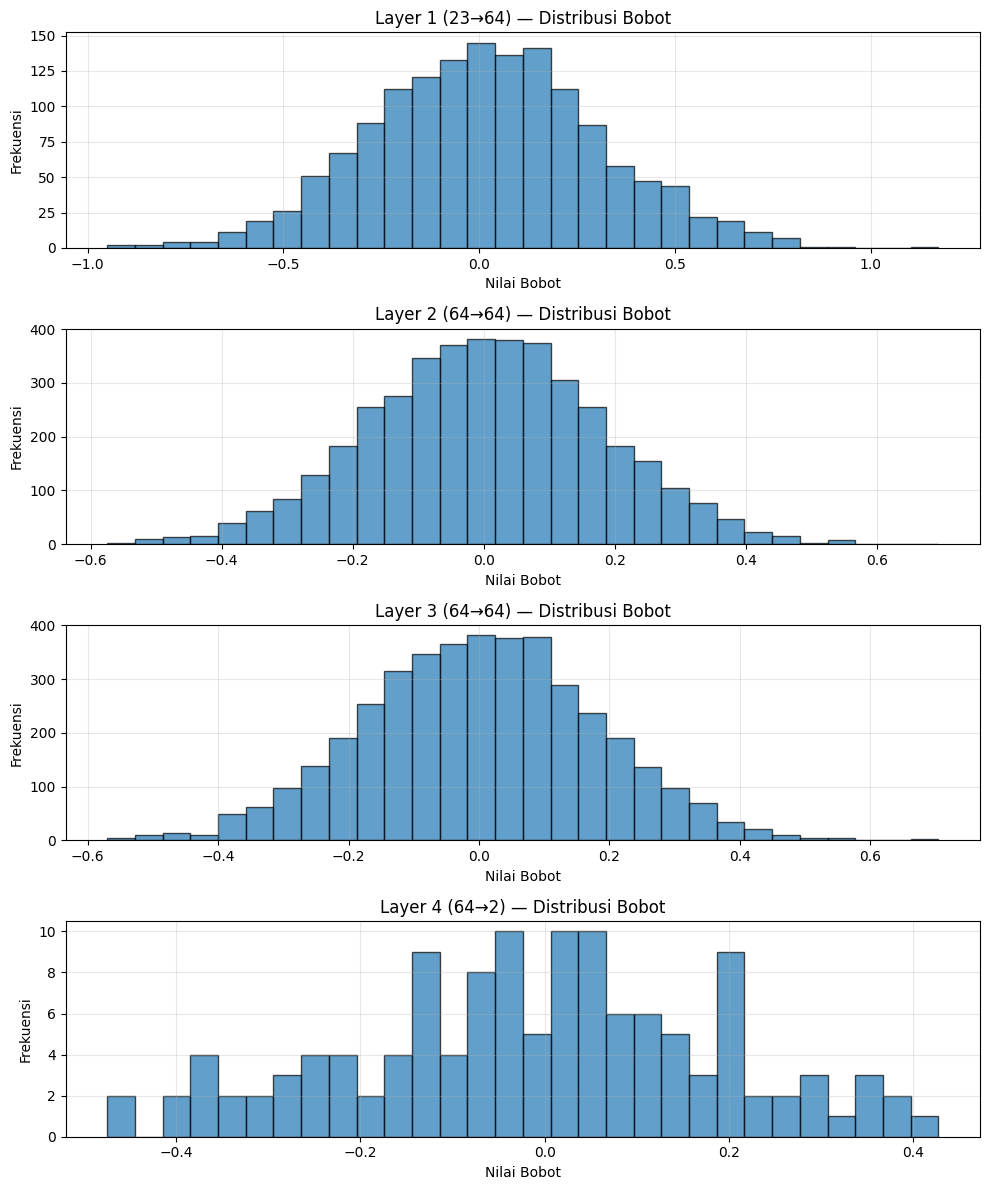

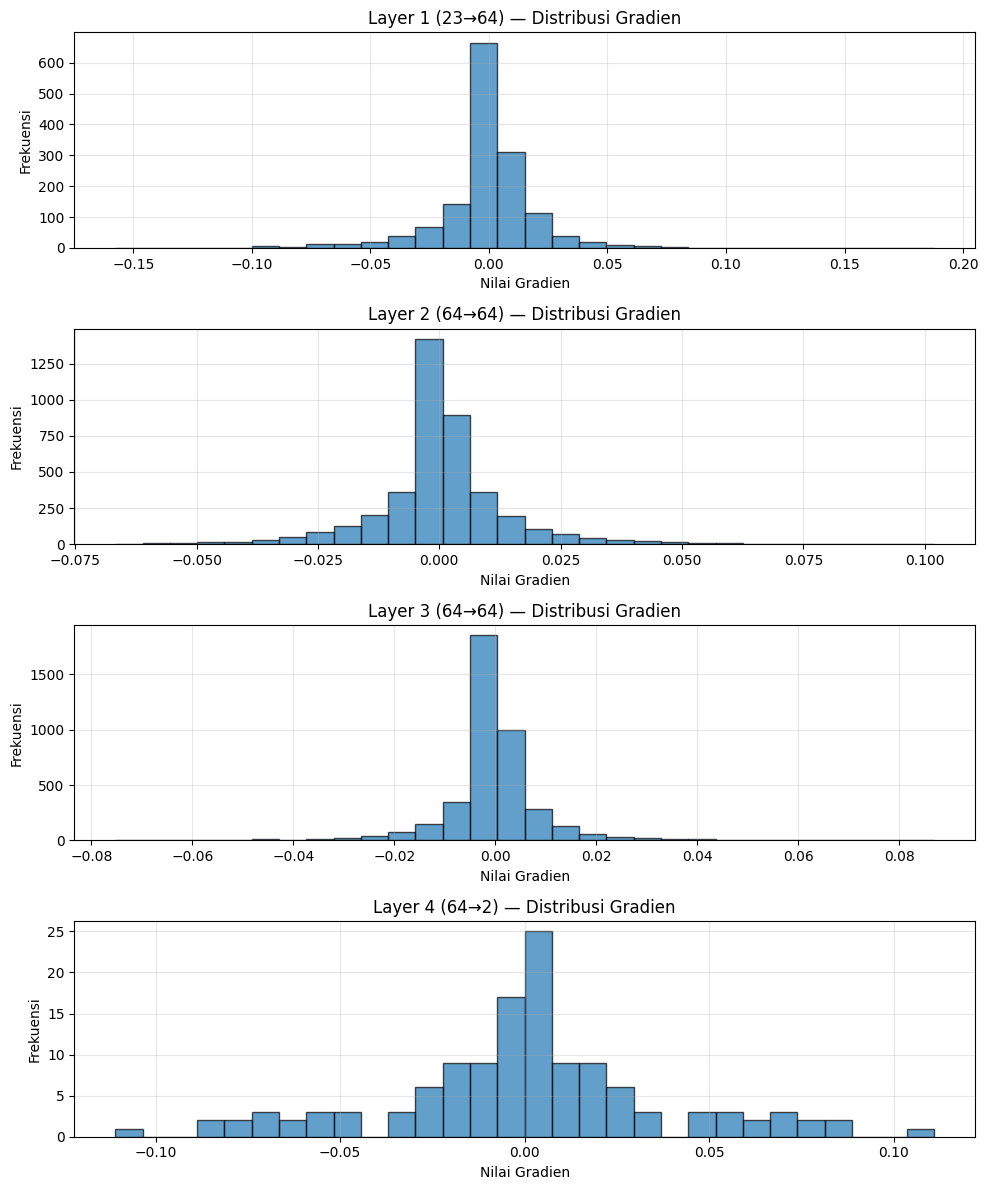

In [69]:
# Distribusi bobot dan gradien 
for act_name, model in act_models.items():
    print(f'\n- Aktivasi: {act_name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 3. Pengaruh Learning Rate

**3 variasi learning rate:** 0.001 (kecil), 0.01 (sedang), 0.1 (besar).

In [70]:
lr_values = [0.001, 0.01, 0.1]

lr_models = {}
lr_results = []

base_arch = [n_features, 64, 64, 64, n_classes]
base_acts = ['relu', 'relu', 'relu', 'softmax']

for lr in lr_values:
    name = f'LR={lr}'
    print(f'\n- {name}')
    
    model = FFNN(
        layer_sizes=base_arch,
        activations=base_acts,
        loss='categorical_cross_entropy',
        init_method='he',
        init_params={'distribution': 'normal', 'seed': 42}
    )
    model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=lr, epochs=EPOCHS, verbose=0)
    lr_models[name] = model
    res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
    lr_results.append(res)


- LR=0.001
LR=0.001:
  Train Accuracy: 0.7361
  Val Accuracy:   0.7167
  Test Accuracy:  0.7020

- LR=0.01
LR=0.01:
  Train Accuracy: 0.7839
  Val Accuracy:   0.7407
  Test Accuracy:  0.7273

- LR=0.1
LR=0.1:
  Train Accuracy: 0.8650
  Val Accuracy:   0.7227
  Test Accuracy:  0.7200


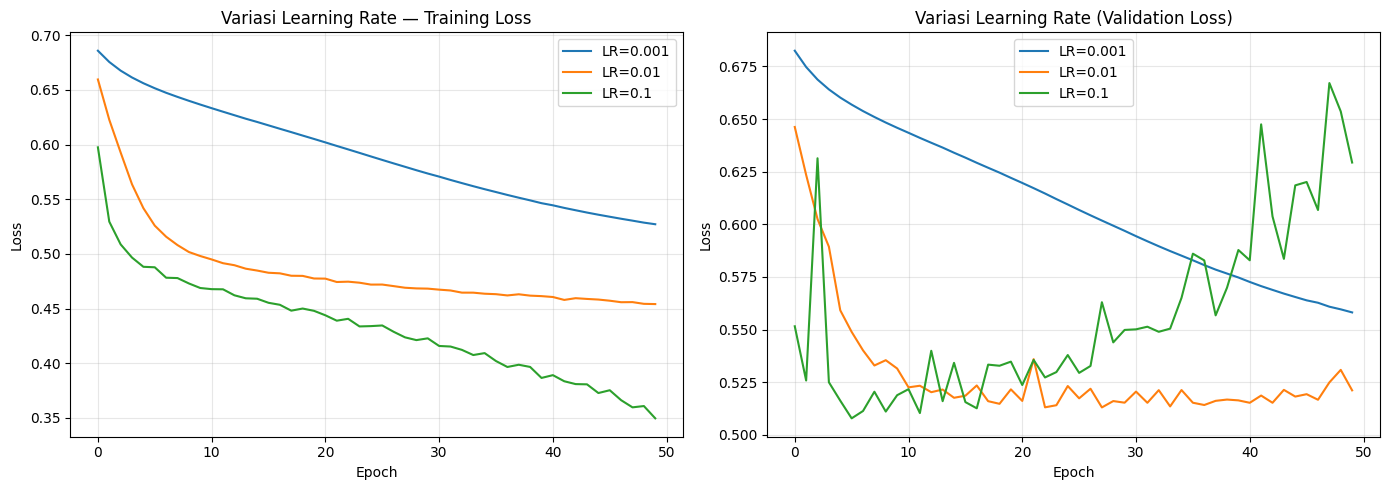

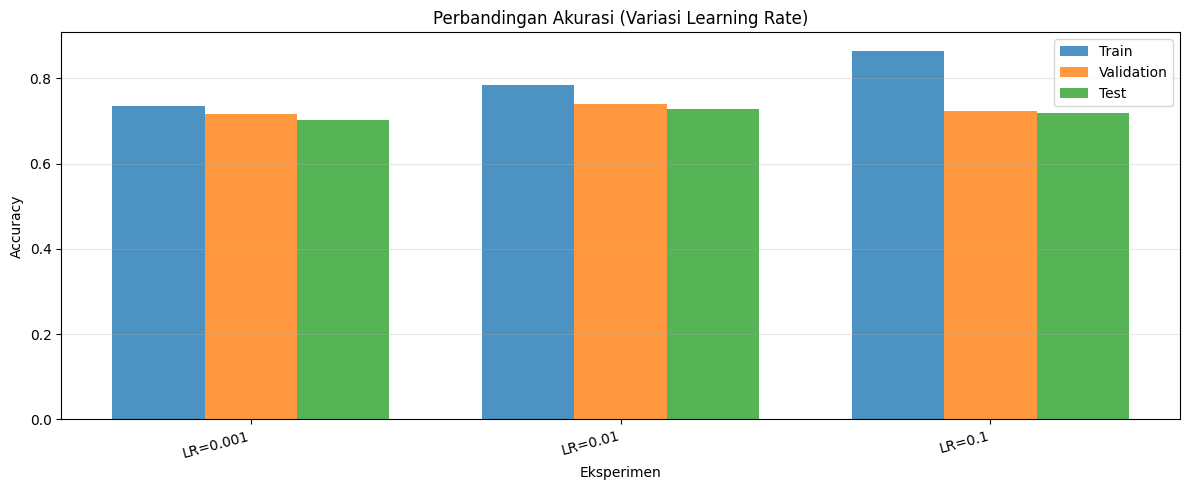

In [71]:
compare_loss(lr_models, 'Variasi Learning Rate')
compare_accuracy_bar(lr_results, 'Perbandingan Akurasi (Variasi Learning Rate)')


- LR=0.001


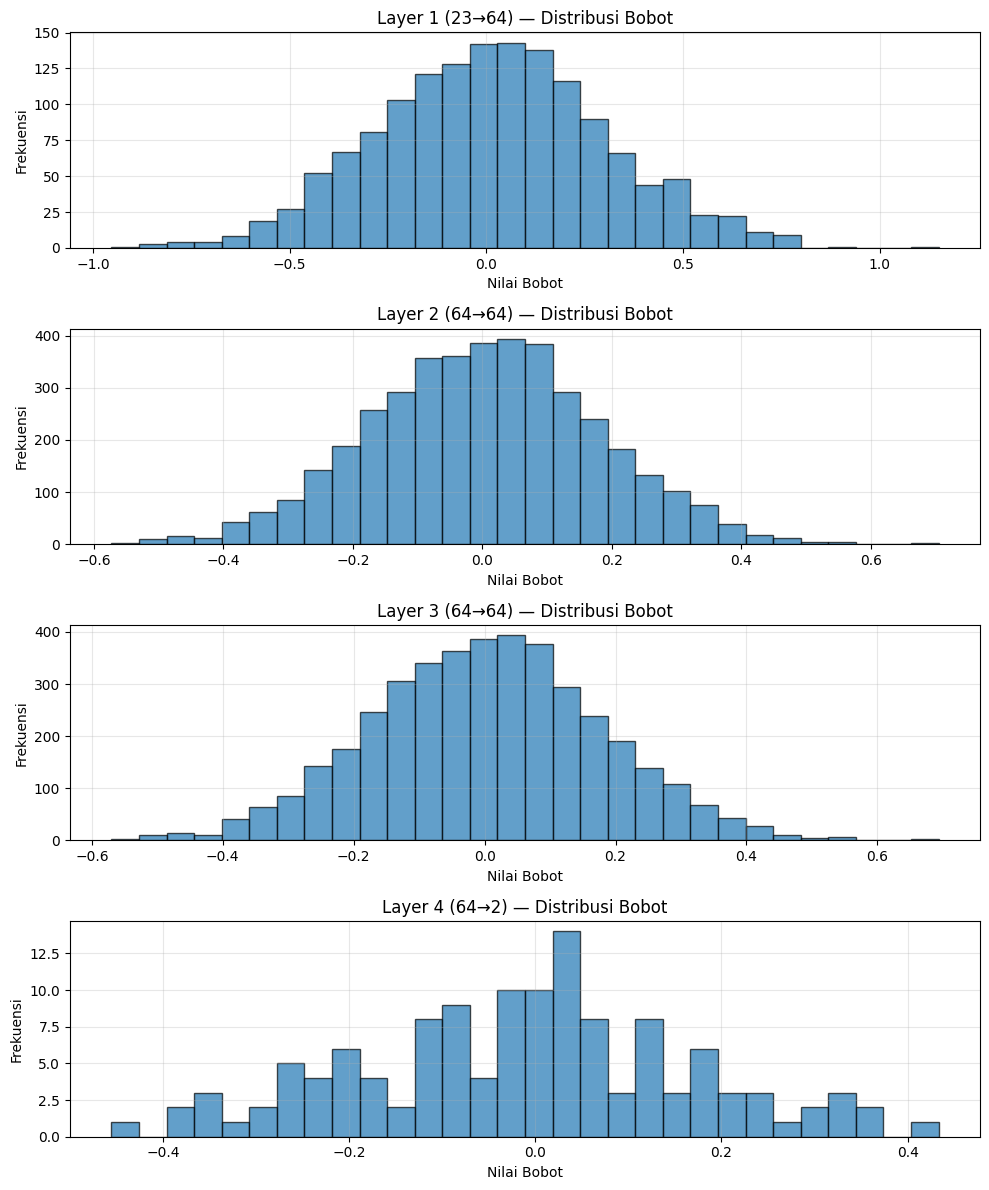

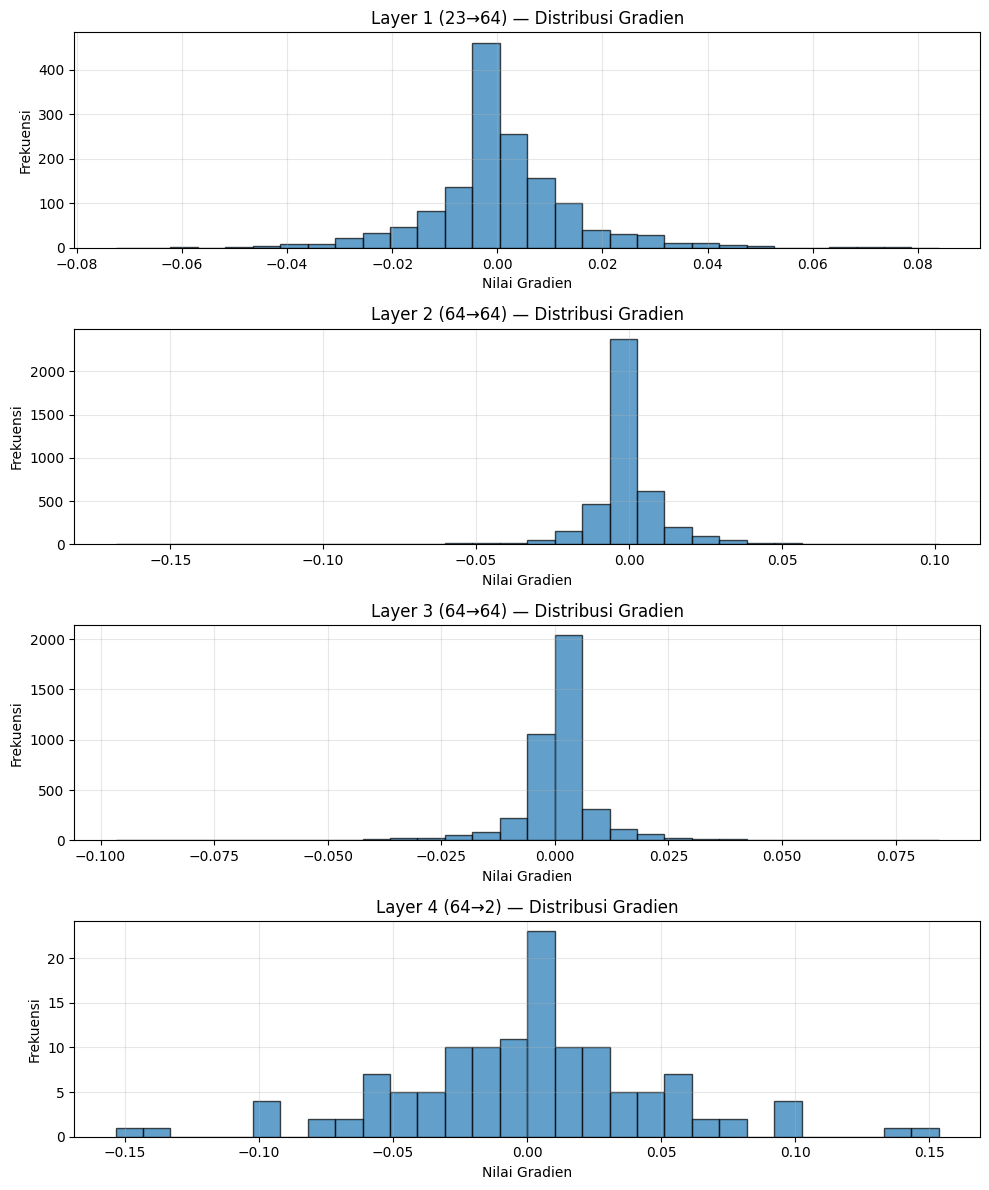


- LR=0.01


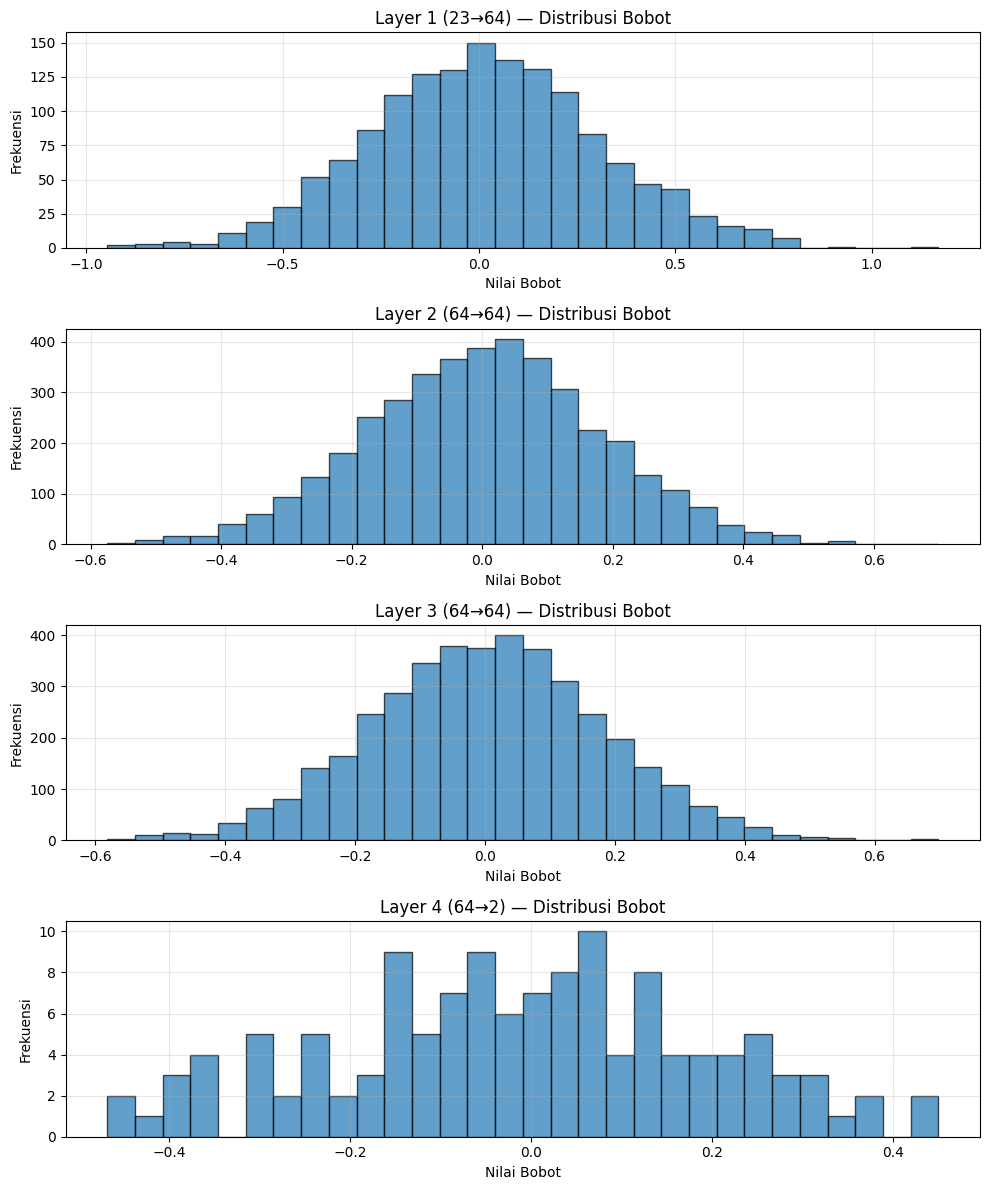

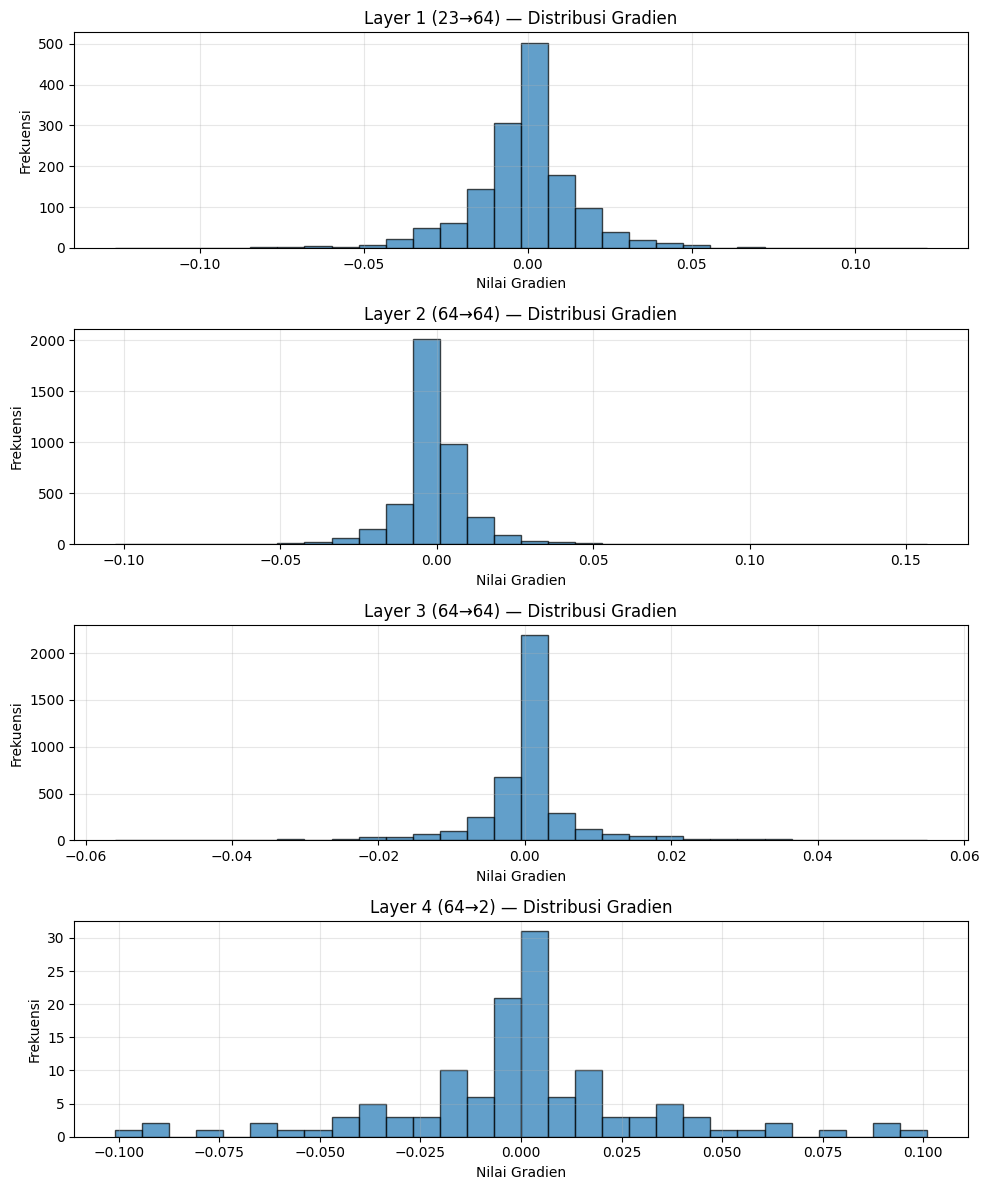


- LR=0.1


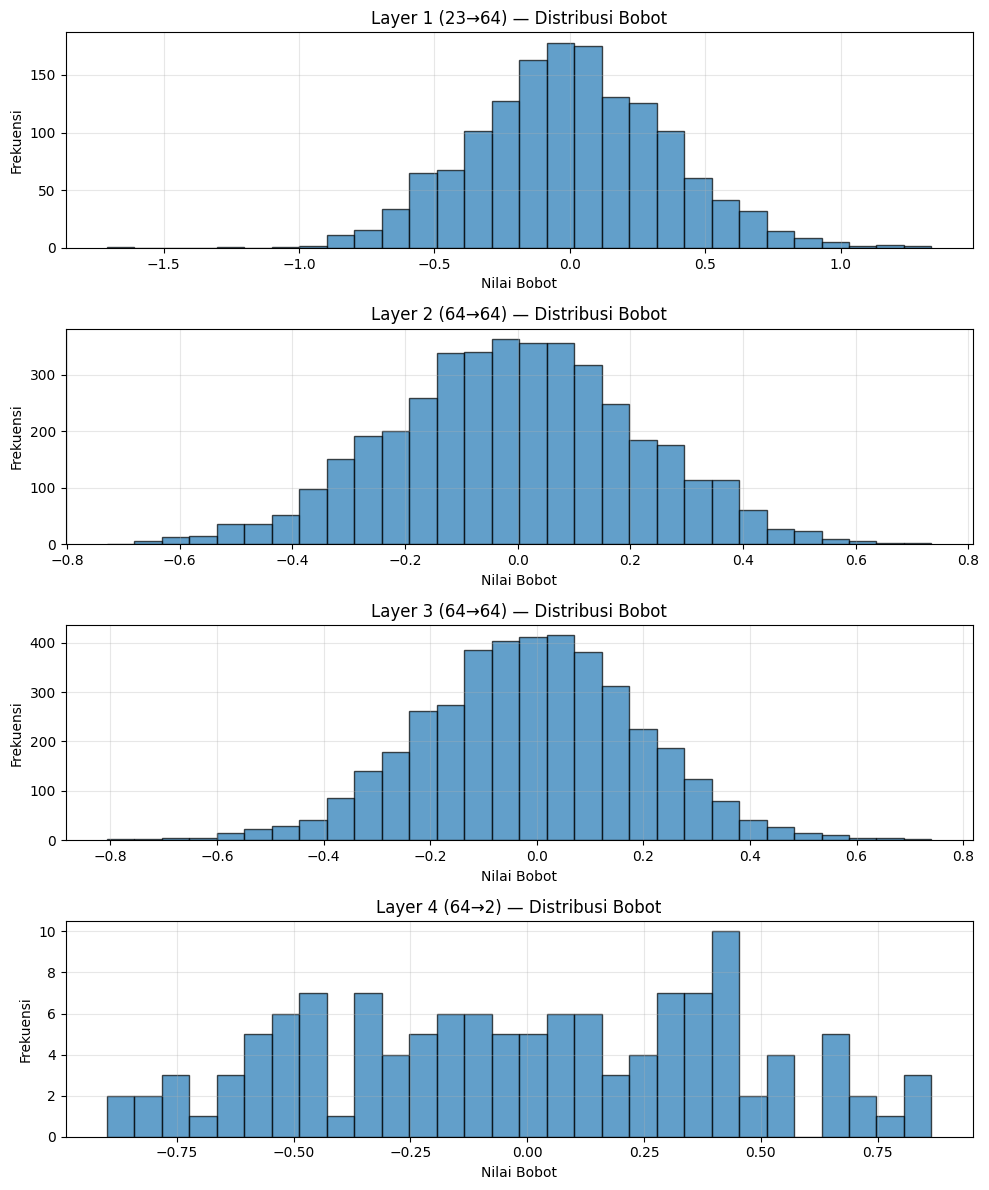

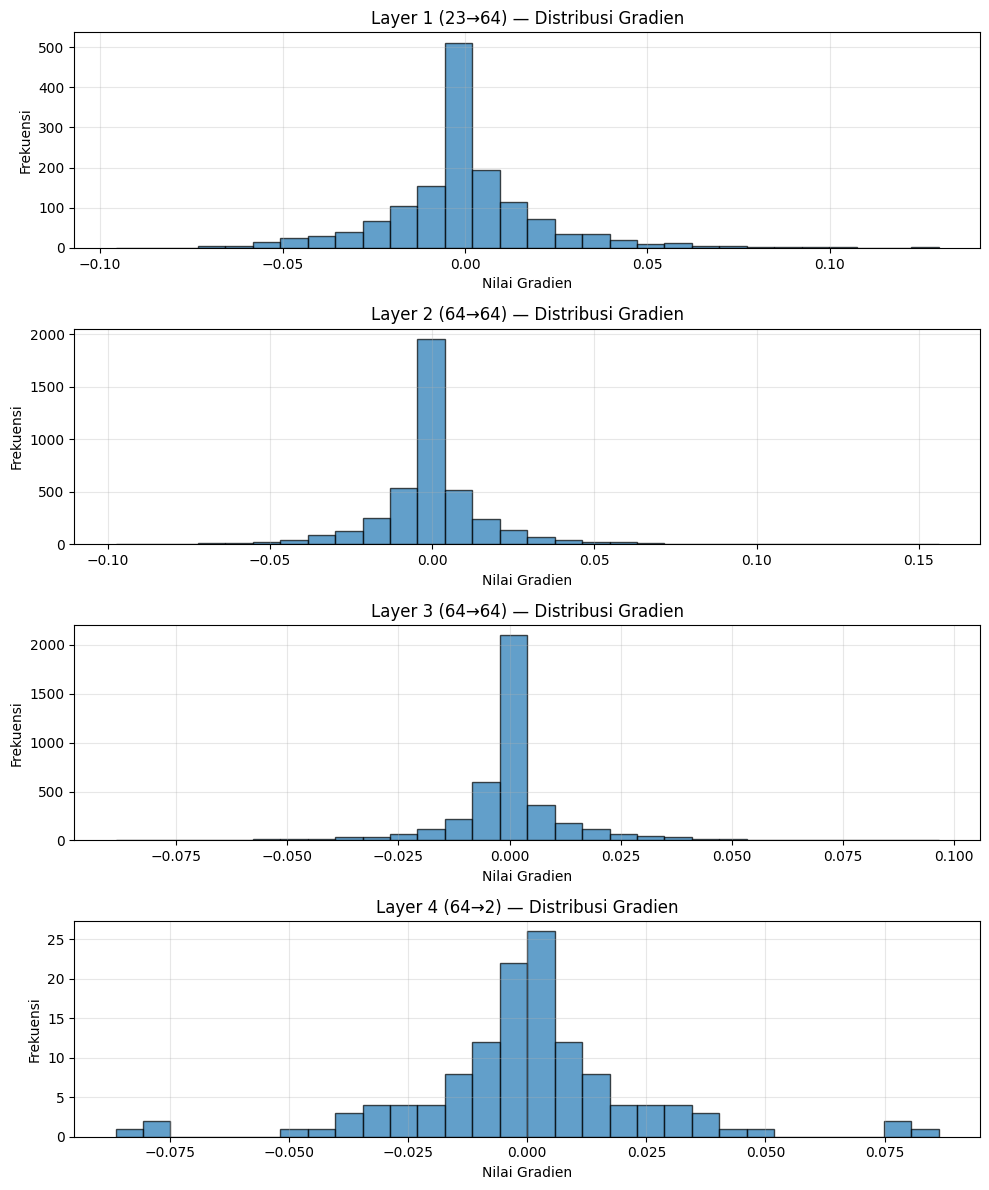

In [72]:
for name, model in lr_models.items():
    print(f'\n- {name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 4. Pengaruh Regularisasi

**3 variasi:** tanpa regularisasi, L1 (λ=0.001), L2 (λ=0.001).

In [73]:
reg_configs = {
    'Tanpa Regularisasi': {'l1_lambda': 0.0, 'l2_lambda': 0.0},
    'L1 (λ=0.001)':      {'l1_lambda': 0.001, 'l2_lambda': 0.0},
    'L2 (λ=0.001)':      {'l1_lambda': 0.0, 'l2_lambda': 0.001},
}

reg_models = {}
reg_results = []

for name, reg_params in reg_configs.items():
    print(f'\n- {name}')
    
    model = FFNN(
        layer_sizes=base_arch,
        activations=base_acts,
        loss='categorical_cross_entropy',
        init_method='he',
        init_params={'distribution': 'normal', 'seed': 42}
    )
    model.train(
        X_train, y_train, X_val, y_val,
        batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0,
        **reg_params
    )
    reg_models[name] = model
    res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
    reg_results.append(res)


- Tanpa Regularisasi
Tanpa Regularisasi:
  Train Accuracy: 0.7874
  Val Accuracy:   0.7327
  Test Accuracy:  0.7333

- L1 (λ=0.001)
L1 (λ=0.001):
  Train Accuracy: 0.7713
  Val Accuracy:   0.7473
  Test Accuracy:  0.7327

- L2 (λ=0.001)
L2 (λ=0.001):
  Train Accuracy: 0.7839
  Val Accuracy:   0.7440
  Test Accuracy:  0.7373


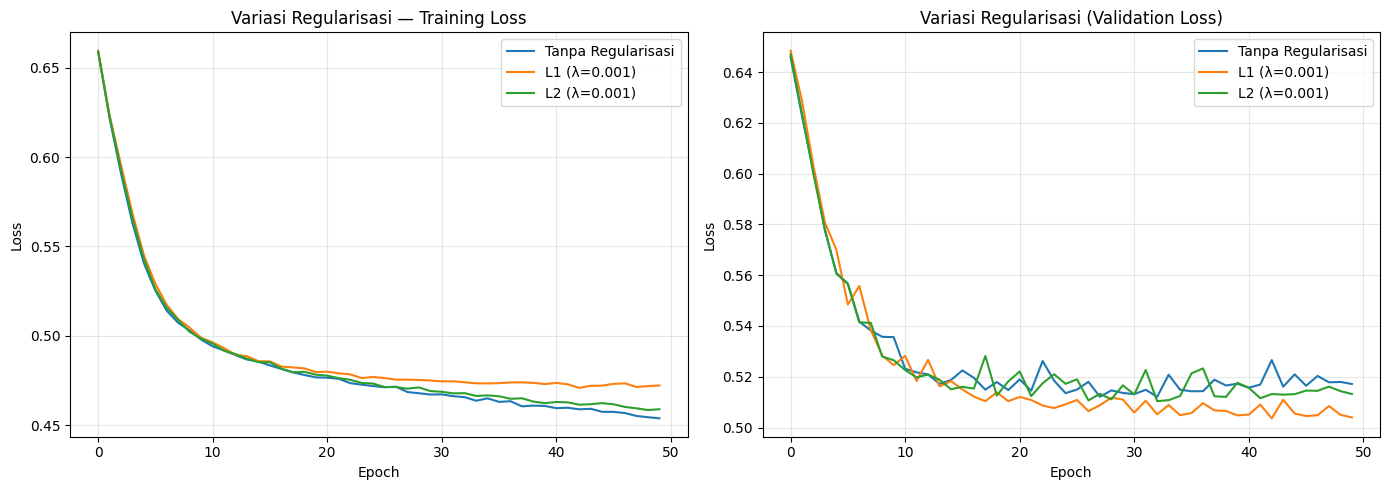

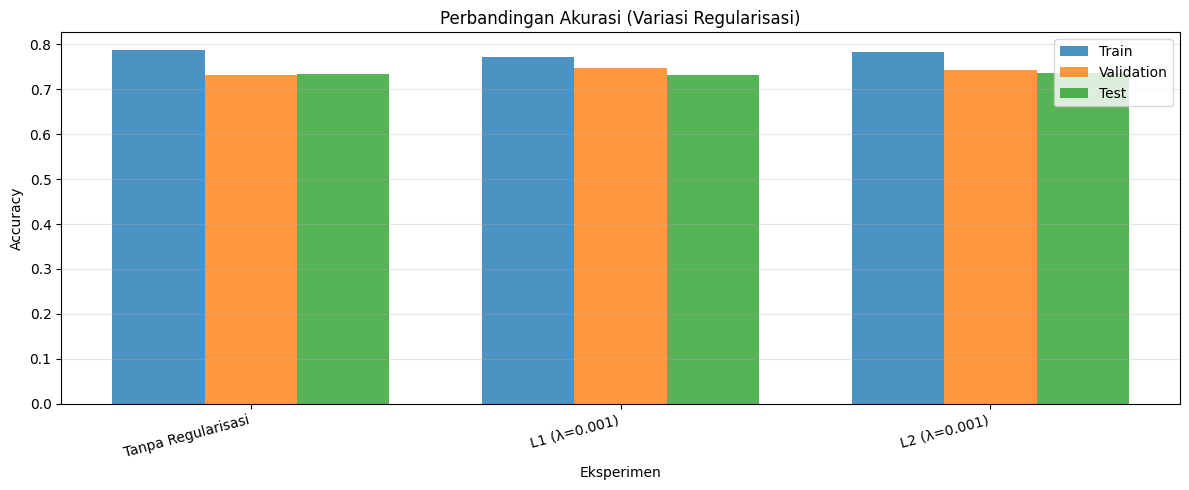

In [74]:
compare_loss(reg_models, 'Variasi Regularisasi')
compare_accuracy_bar(reg_results, 'Perbandingan Akurasi (Variasi Regularisasi)')


- Tanpa Regularisasi


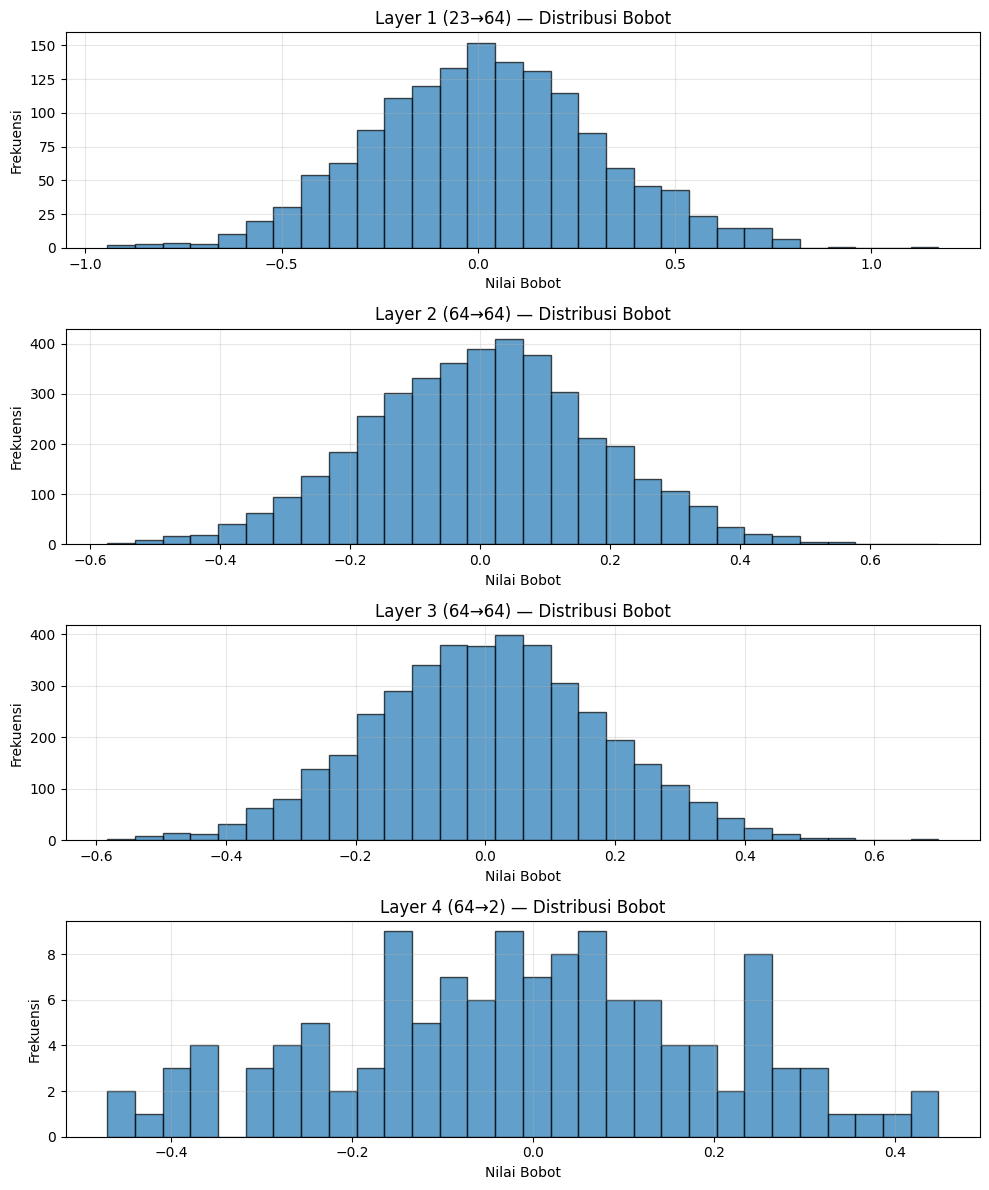

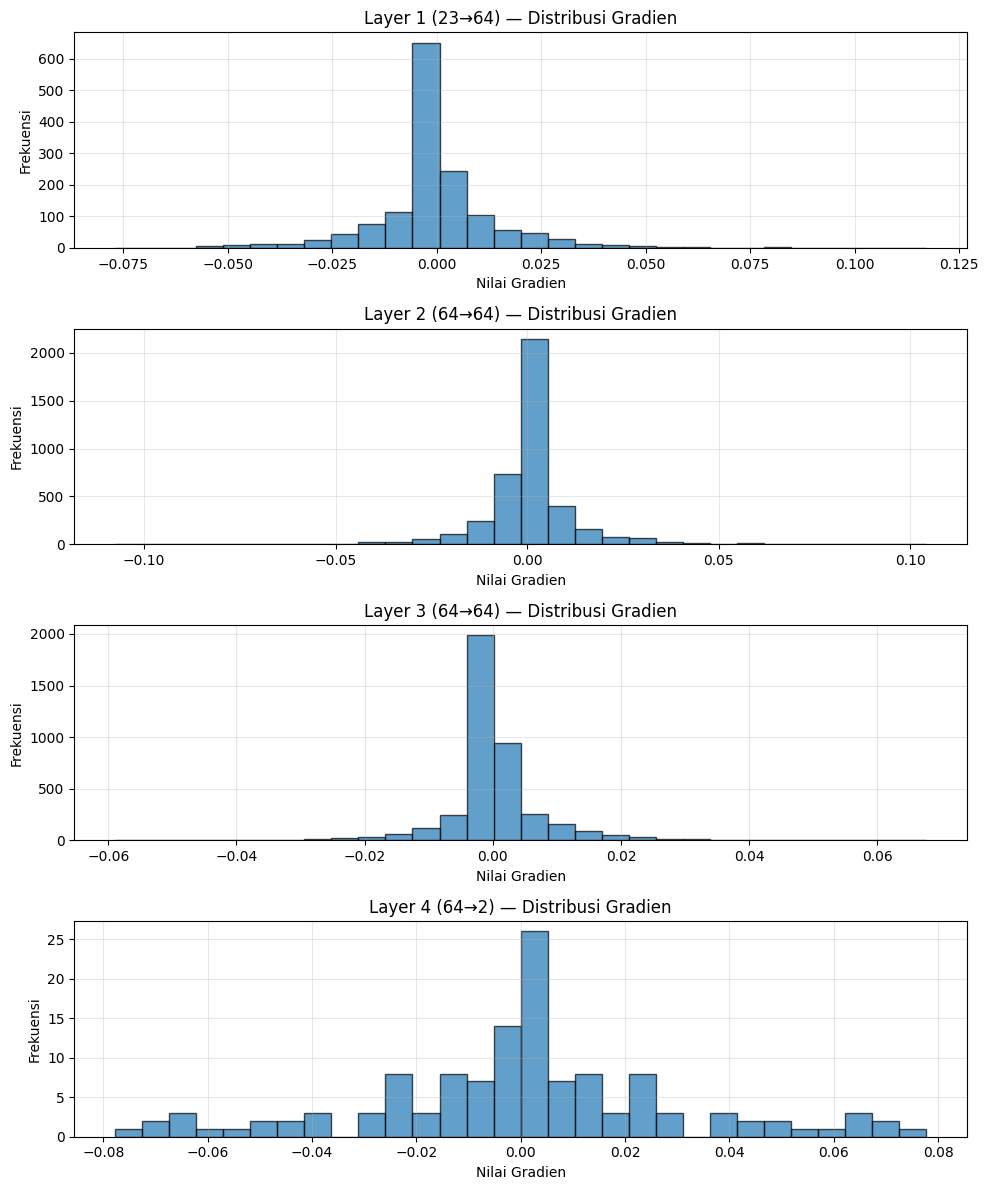


- L1 (λ=0.001)


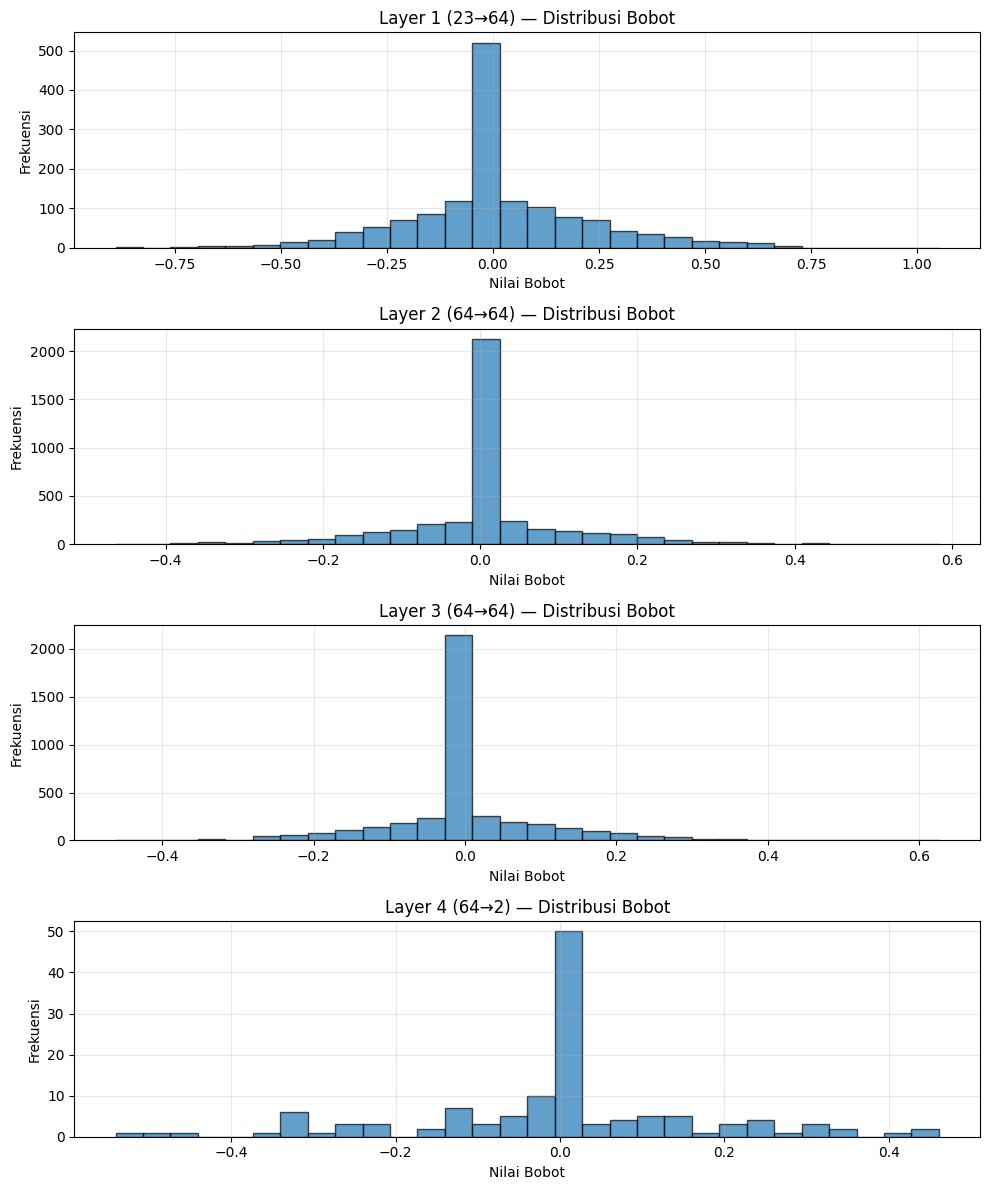

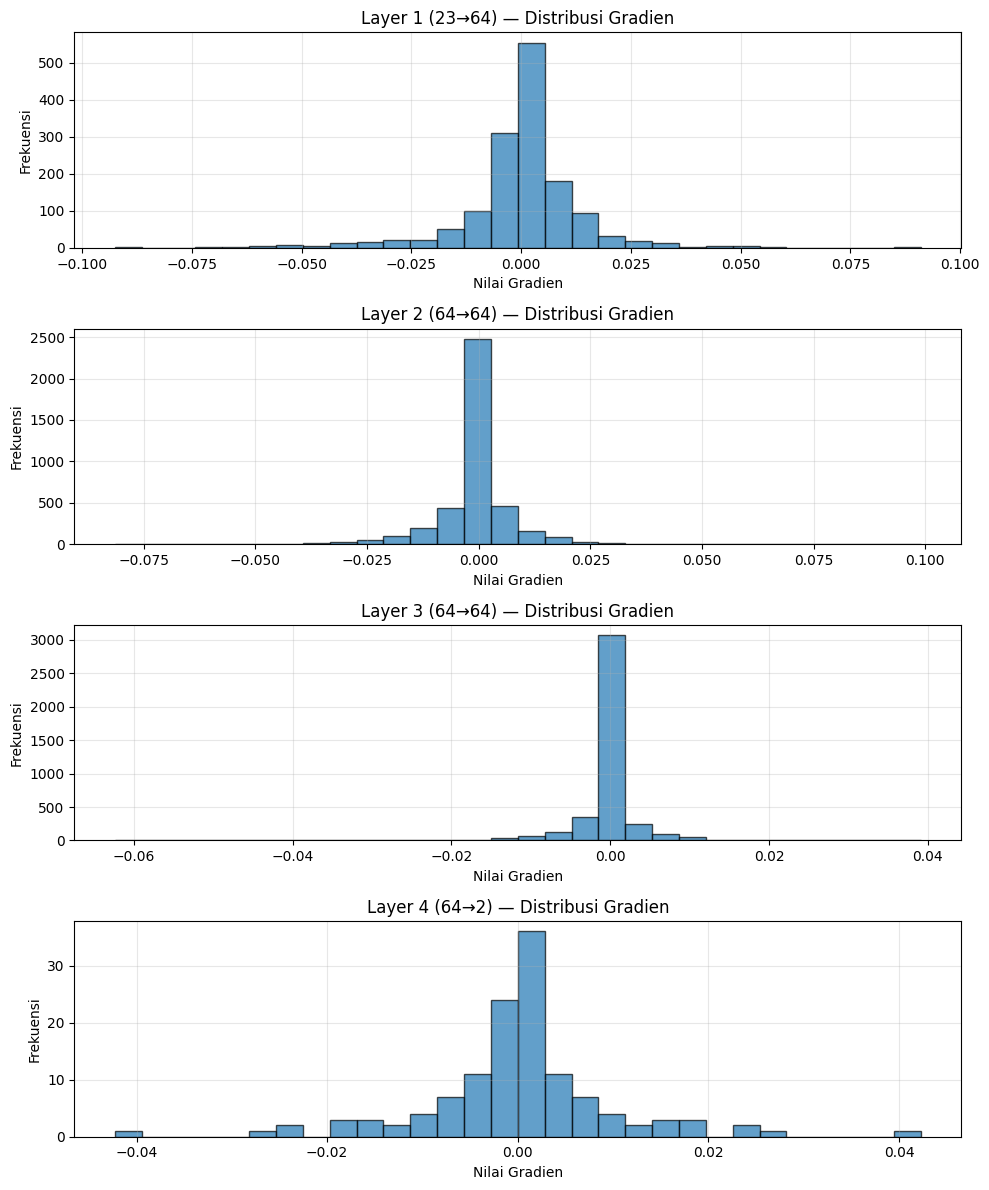


- L2 (λ=0.001)


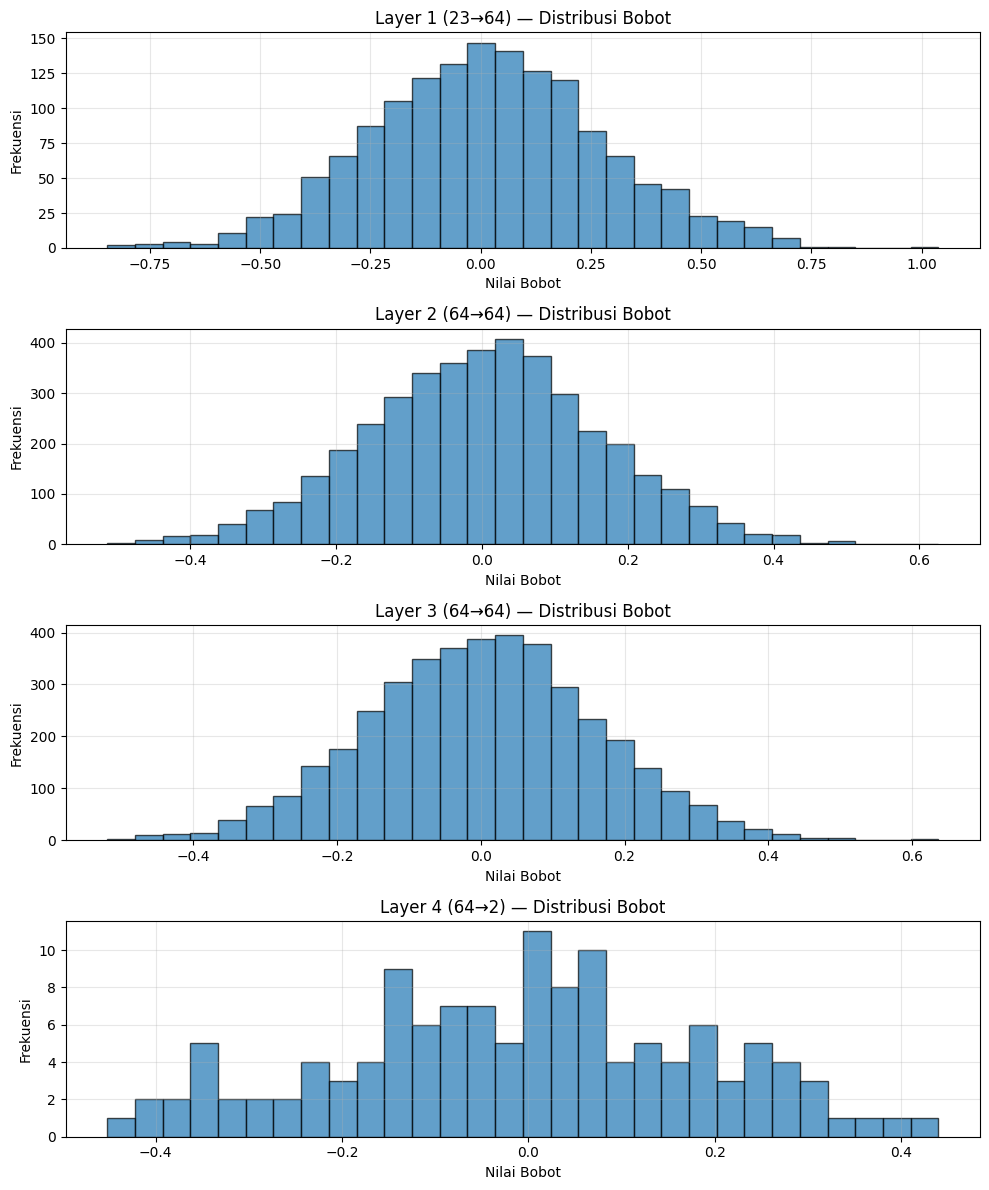

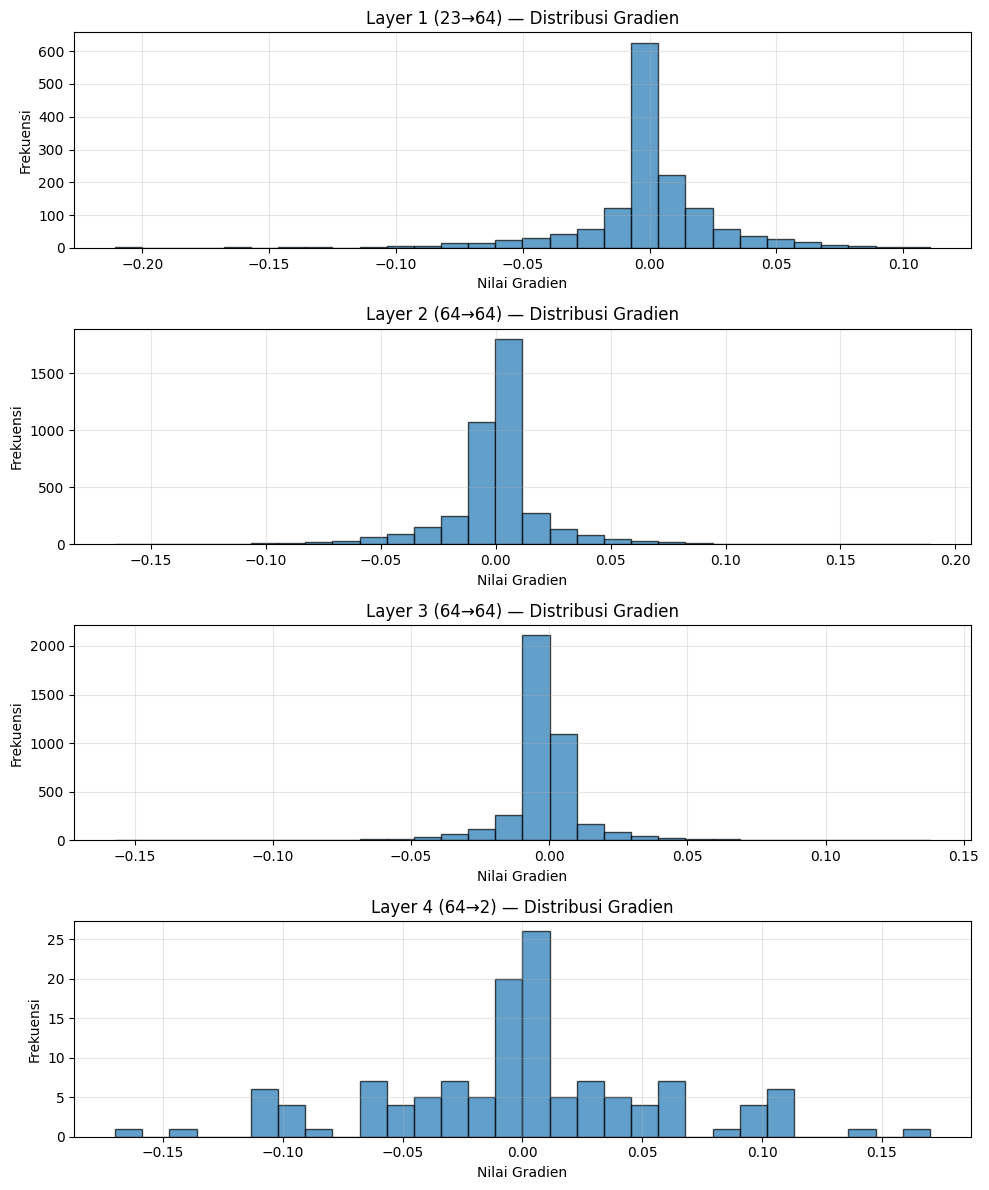

In [75]:
for name, model in reg_models.items():
    print(f'\n- {name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 5. Uji Perbandingan: FFNN vs sklearn MLPClassifier

Hyperparameter:
- Arsitektur: (64, 64, 64) hidden layers
- Fungsi aktivasi: ReLU
- Learning rate: 0.01
- Epochs: 50
- Batch size: 32

In [76]:
print('- FFNN (From Scratch)')
ffnn_model = FFNN(
    layer_sizes=[n_features, 64, 64, 64, n_classes],
    activations=['relu', 'relu', 'relu', 'softmax'],
    loss='categorical_cross_entropy',
    init_method='he',
    init_params={'distribution': 'normal', 'seed': 42}
)
ffnn_model.train(X_train, y_train, X_val, y_val, batch_size=32, learning_rate=0.01, epochs=50, verbose=0)

ffnn_train_acc = accuracy(ffnn_model, X_train, y_train)
ffnn_val_acc = accuracy(ffnn_model, X_val, y_val)
ffnn_test_acc = accuracy(ffnn_model, X_test, y_test)
print(f'  Train Accuracy: {ffnn_train_acc:.4f}')
print(f'  Val Accuracy:   {ffnn_val_acc:.4f}')
print(f'  Test Accuracy:  {ffnn_test_acc:.4f}')

- FFNN (From Scratch)
  Train Accuracy: 0.7871
  Val Accuracy:   0.7400
  Test Accuracy:  0.7353


In [77]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print('\n- Sklearn MLPClassifier')

# Konversi target dari one-hot ke label integer
y_train_labels = np.argmax(y_train, axis=1)
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

sklearn_model = MLPClassifier(
    hidden_layer_sizes=(64, 64, 64),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=50,
    random_state=42,
    verbose=False
)
sklearn_model.fit(X_train, y_train_labels)

sk_train_acc = accuracy_score(y_train_labels, sklearn_model.predict(X_train))
sk_val_acc = accuracy_score(y_val_labels, sklearn_model.predict(X_val))
sk_test_acc = accuracy_score(y_test_labels, sklearn_model.predict(X_test))
print(f'  Train Accuracy: {sk_train_acc:.4f}')
print(f'  Val Accuracy:   {sk_val_acc:.4f}')
print(f'  Test Accuracy:  {sk_test_acc:.4f}')


- Sklearn MLPClassifier
  Train Accuracy: 0.8074
  Val Accuracy:   0.7413
  Test Accuracy:  0.7153


C:\Users\Matthew\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


              Model  Train Accuracy  Validation Accuracy  Test Accuracy
FFNN (From Scratch)        0.787143             0.740000       0.735333
        sklearn MLP        0.807429             0.741333       0.715333


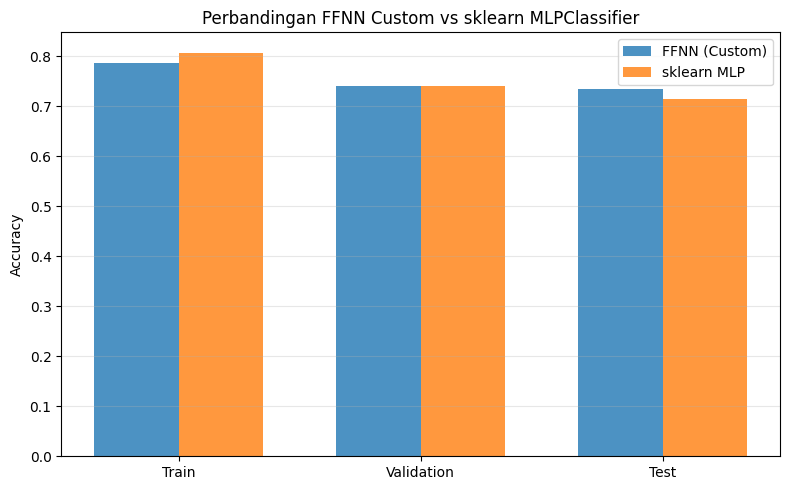

In [78]:
comparison = pd.DataFrame({
    'Model': ['FFNN (From Scratch)', 'sklearn MLP'],
    'Train Accuracy': [ffnn_train_acc, sk_train_acc],
    'Validation Accuracy': [ffnn_val_acc, sk_val_acc],
    'Test Accuracy': [ffnn_test_acc, sk_test_acc]
})
print(comparison.to_string(index=False))

# Bar chart perbandingan
x = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [ffnn_train_acc, ffnn_val_acc, ffnn_test_acc], width, label='FFNN (Custom)', alpha=0.8)
ax.bar(x + width/2, [sk_train_acc, sk_val_acc, sk_test_acc], width, label='sklearn MLP', alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan FFNN Custom vs sklearn MLPClassifier')
ax.set_xticks(x)
ax.set_xticklabels(['Train', 'Validation', 'Test'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 6. Bonus: RMSNorm — Normalisasi pada Hidden Layer

Eksperimen membandingkan model **tanpa normalisasi** vs **dengan RMSNorm** pada semua hidden layer.

**Arsitektur:** [n_features, 64, 64, 64, n_classes], ReLU activation, CCE loss.

In [79]:
norm_configs = {
    'Tanpa Normalisasi': None,
    'Dengan RMSNorm': True,  # RMSNorm pada semua layer
}

norm_models = {}
norm_results = []

for name, norm_flag in norm_configs.items():
    print(f'\n- {name}')
    
    model = FFNN(
        layer_sizes=base_arch,
        activations=base_acts,
        loss='categorical_cross_entropy',
        init_method='he',
        init_params={'distribution': 'normal', 'seed': 42},
        normalization=norm_flag
    )
    model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0)
    norm_models[name] = model
    res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
    norm_results.append(res)


- Tanpa Normalisasi
Tanpa Normalisasi:
  Train Accuracy: 0.7803
  Val Accuracy:   0.7433
  Test Accuracy:  0.7273

- Dengan RMSNorm
Dengan RMSNorm:
  Train Accuracy: 0.8061
  Val Accuracy:   0.7347
  Test Accuracy:  0.7193


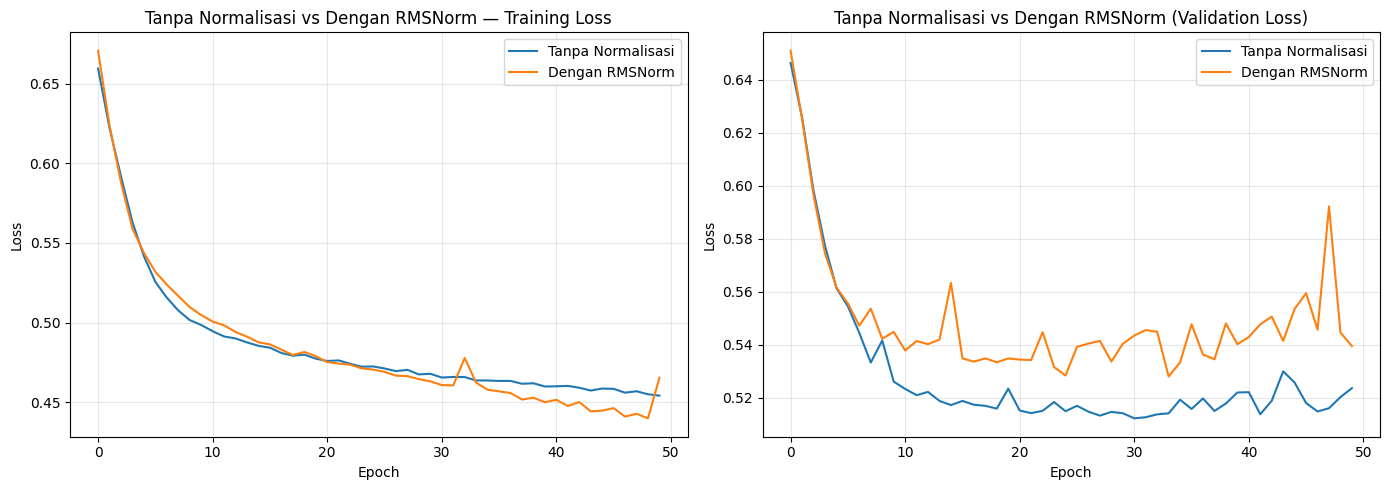

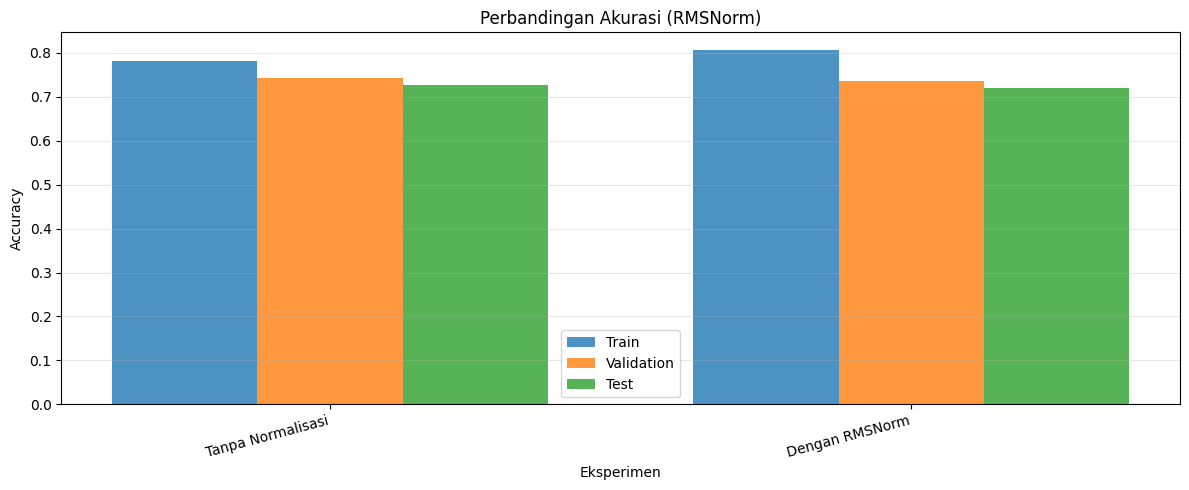

In [80]:
compare_loss(norm_models, 'Tanpa Normalisasi vs Dengan RMSNorm')
compare_accuracy_bar(norm_results, 'Perbandingan Akurasi (RMSNorm)')


- Tanpa Normalisasi


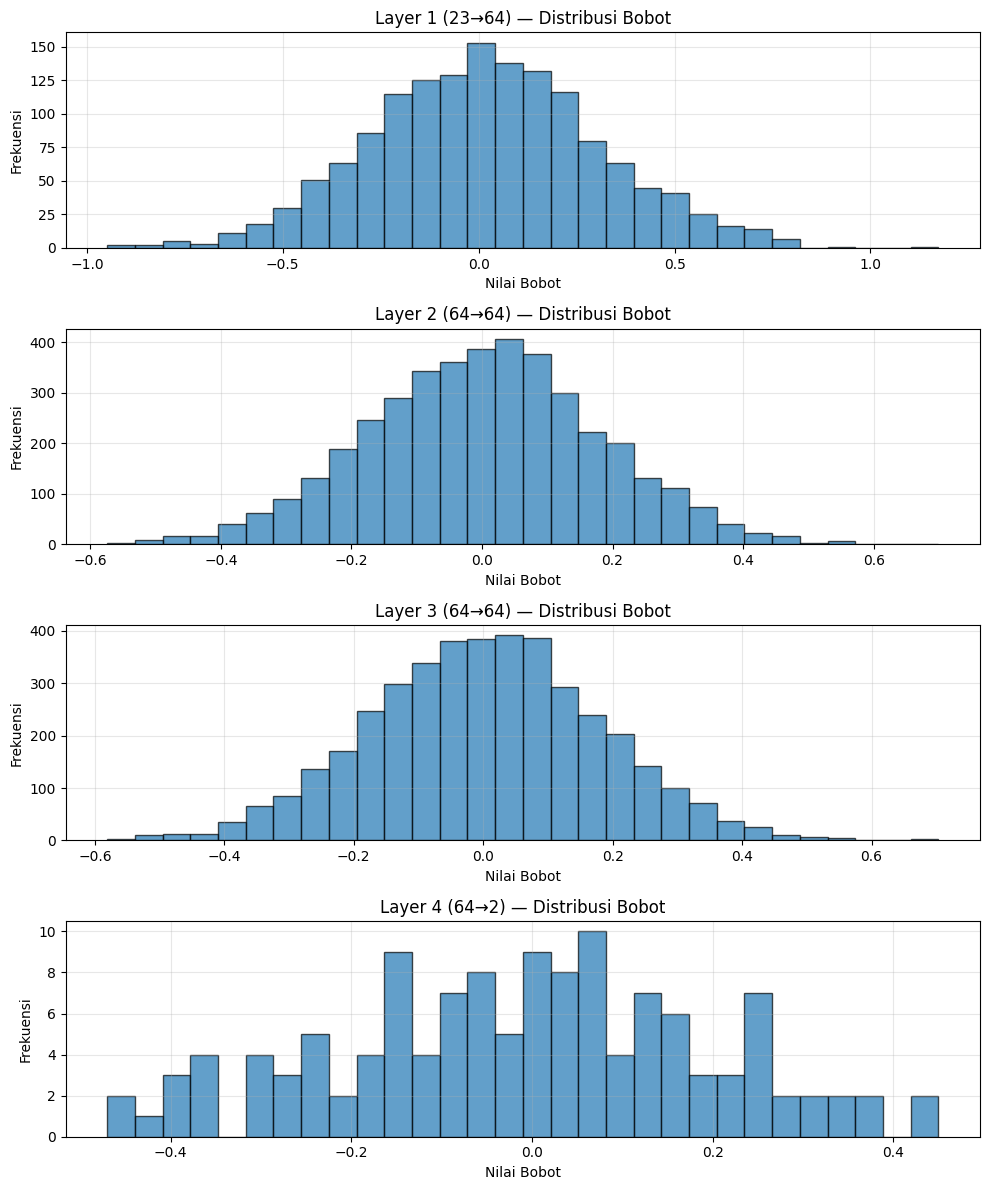

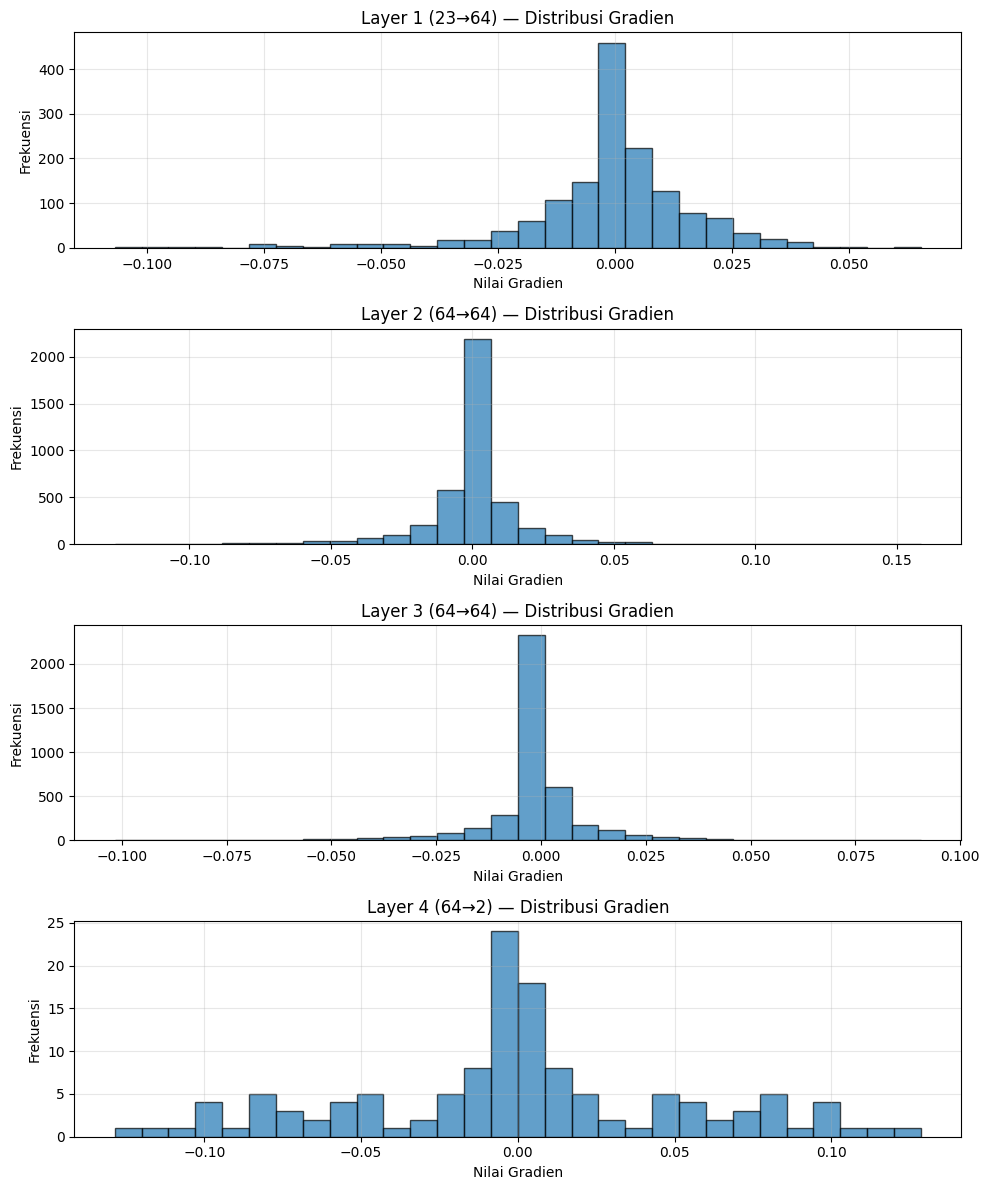


- Dengan RMSNorm


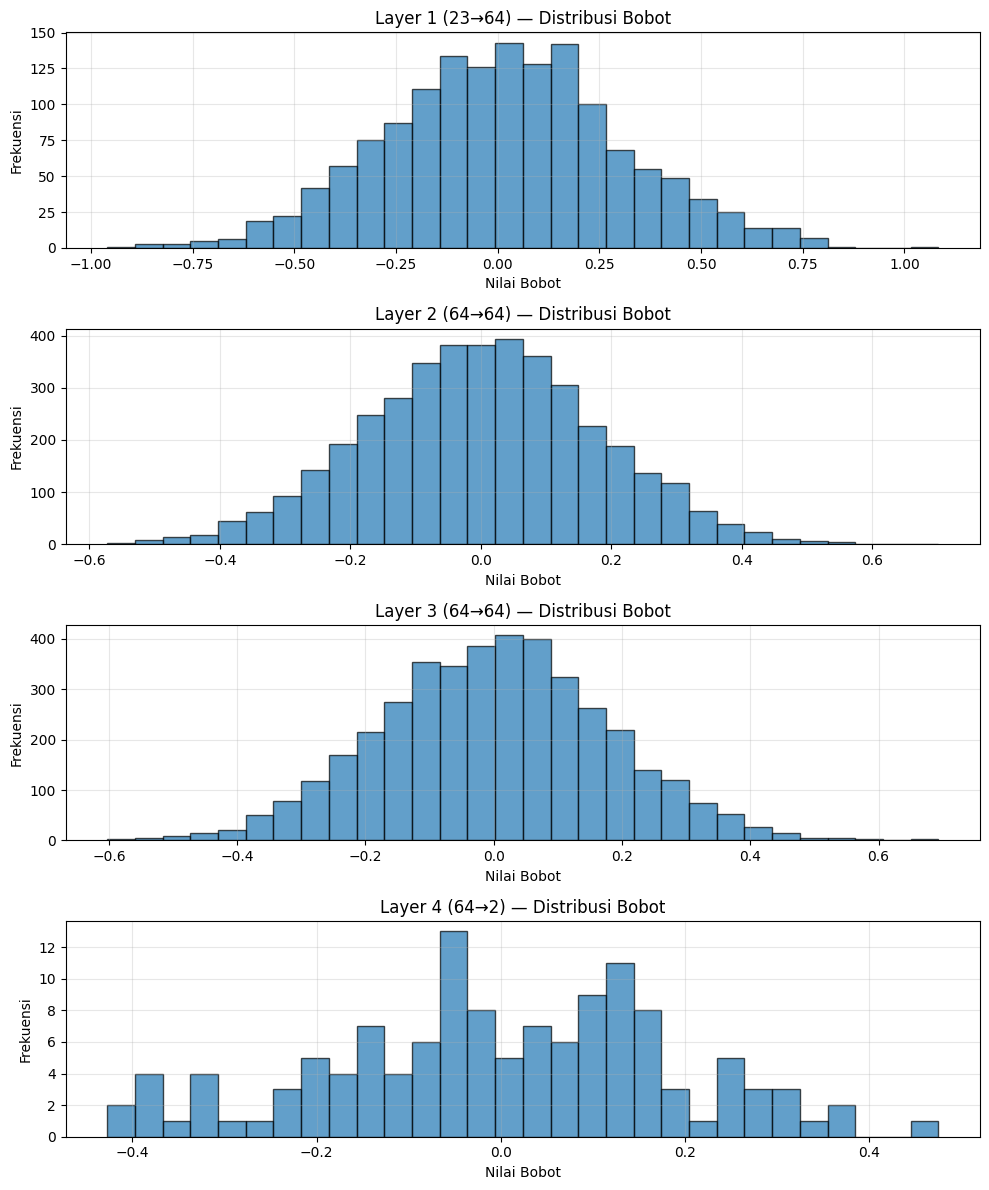

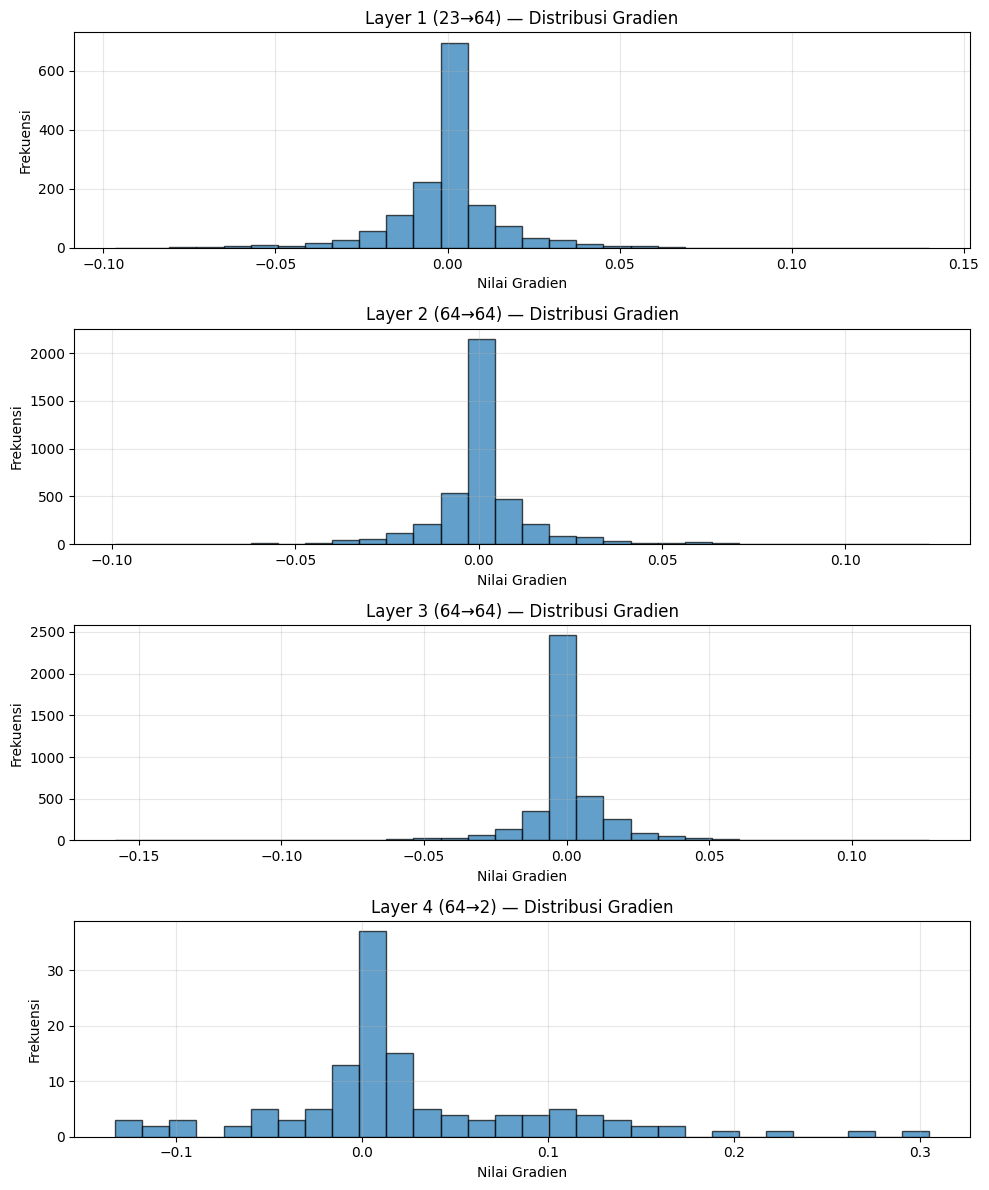

In [81]:
for name, model in norm_models.items():
    print(f'\n- {name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## Ringkasan Hasil

In [82]:
all_results = []
all_results.extend([{**r, 'Kategori': 'Width'} for r in width_results])
all_results.extend([{**r, 'Kategori': 'Depth'} for r in depth_results])
all_results.extend([{**r, 'Kategori': 'Aktivasi'} for r in act_results])
all_results.extend([{**r, 'Kategori': 'Learning Rate'} for r in lr_results])
all_results.extend([{**r, 'Kategori': 'Regularisasi'} for r in reg_results])
all_results.extend([{**r, 'Kategori': 'RMSNorm'} for r in norm_results])

summary_df = pd.DataFrame(all_results)
summary_df.columns = ['Eksperimen', 'Train Acc', 'Val Acc', 'Test Acc', 'Kategori']
summary_df = summary_df[['Kategori', 'Eksperimen', 'Train Acc', 'Val Acc', 'Test Acc']]
summary_df

,Kategori,Eksperimen,Train Acc,Val Acc,Test Acc
0,Width,Width=16,0.765143,0.725333,0.732000
1,Width,Width=64,0.778000,0.740000,0.726667
2,Width,Width=128,0.795857,0.741333,0.737333
3,Depth,Depth=1,0.768429,0.747333,0.733333
4,Depth,Depth=3,0.786714,0.738667,0.731333
5,Depth,Depth=5,0.811429,0.746000,0.730667
6,Aktivasi,linear,0.780143,0.748000,0.742000
7,Aktivasi,relu,0.787000,0.739333,0.731333
8,Aktivasi,sigmoid,0.768000,0.746667,0.740667
9,Aktivasi,tanh,0.780286,0.746000,0.731333
